## Intro to Predictive Processing Ecephys NWBs
This notebook just shows how to extract the data-of-interest out of OpenScope's Predictive Process NWB files for Ecephys, which have been uploaded to the DANDI Archive.

The important information from experimental session in these files currently available are:
- Subject information
- Stimulus tables
- LFP (local field potential) traces
- Neuronal unit spike times from Kilosort4 and associated metrics
- Neuropixels probe electrodes table
- Eye tracking on screen (from deeplabcut)
- Running wheel rotation

In [1]:
import sys
print(sys.executable)

/Users/aryan/miniforge3/envs/nwbModern/bin/python


In [2]:
import pynwb
import dandi
import allensdk
print("Setup successful!")

Setup successful!


In [3]:
from dandi import dandiapi
from dandi import download
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO
import os
import matplotlib as mpl

%matplotlib inline

### Download and Open NWB file
The NWB files can be found in Dandiset 001424 on DANDI [here](https://dandiarchive.org/dandiset/001637?pos=1). The NWB can be downloaded with the DANDI client and then opened with pynwb

In [4]:
import os

# Get the current working directory
notebook_dir = os.getcwd()
print(notebook_dir)


/Users/aryan/Desktop/NajafiLab/allen_project_openscope


In [5]:
# --- Configuration ---
# Dandiset ID for Allen Ecephys NWB files
dandiset_id = "001637"

# Sessions to choose from:
# Sunject ID: 820459
    # "sub-820459/sub-820459_ses-ecephys-820459-2025-11-12-14-34-33_ecephys.nwb"
    # "sub-820459/sub-820459_ses-ecephys-820459-2025-11-10-15-07-13_ecephys.nwb"
# Subject ID: 820454
    # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-07-10-54-23_ecephys.nwb"
    # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-06-16-00-27_ecephys.nwb"
    # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-05-15-21-15_ecephys.nwb"
    # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"


dandi_filepath = "sub-820454/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"

# Modify this to your desired download location
download_loc = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope"

client = dandiapi.DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id)
file = dandiset.get_asset_by_path(dandi_filepath)
file_url = file.download_url
filename = dandi_filepath.split("/")[-1]
filepath = f"{download_loc}/{filename}"
if os.path.exists(filepath):
    print("File already exists")
else:
    # This can sometimes take a while depending on the size of the file and your internet connection
    download.download(file_url, output_dir=download_loc)
    print(f"Downloaded file to {filepath}")

File already exists


### Open NWB File

NOTE: if you have problems opening the file with an error like "missing namespace core", try updating your pynwb and hdmf versions using
`pip install --upgrade pynwb hdmf`

In [6]:
# the download code above will set filepath according to your download location
# filepath = r"/root/capsule/data/ecephys_820459_2025-11-12_14-34-33_nwb_2025-11-23_02-55-05/ecephys_820459_2025-11-12_14-34-33_experiment1_recording1.nwb"

io = NWBHDF5IO(filepath, mode="r", load_namespaces=True)
nwb = io.read()

/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using

In [7]:
nwb

Data type,float32
Shape,"(259321,)"
Array size,1012.97 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),1037284
Compressed size (bytes),1037284
Compression ratio,1.0
Data type,float64
Shape,"(259321,)"


### Subject Metadata

In [8]:
nwb.subject

subject pynwb.file.Subject at 0x6273356832
Fields:
  age: P100D
  age__reference: birth
  date_of_birth: 2025-07-27 00:00:00-07:53
  genotype: Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
  sex: M
  species: Mus musculus
  subject_id: 820454

### Stimulus

# Experimental Design: Mismatch & Control Blocks

**Project Reference:** [OpenScope Community Predictive Processing](https://allenneuraldynamics.github.io/openscope-community-predictive-processing/) <br>
**Relevant Paper:** [Predictive Processing in Mouse Visual Cortex (arXiv:2504.09614)](https://arxiv.org/pdf/2504.09614)

## 1. Overview of Session Types
This dataset focuses on predictive processing using "mismatch" paradigms. The experiment is designed to distinguish between neural responses driven by **sensory input**, **motor action**, and **predictive error** (oddballs).

The sessions are generally divided into:
1.  **Sensory-motor mismatch:** Closed-loop visual flow coupled to running speed.
2.  **Sequence mismatch:** Fixed sequences of elements where the order is violated.
3.  **Standard mismatch:** 
4.  **Duration mismatch:** Standard drifting gratings where the *duration* is the violation.

## 2. Understanding the Control Blocks
The **Control Blocks** serve a specific statistical purpose distinct from the main experimental blocks.

### The "Shuffled Context" Hypothesis
The Control blocks are designed to present **all trial types** found in the main blocks but in a **shuffled context**.
* **Purpose:** To rule out long-term adaptation effects caused by the specific intervals between oddball presentations in the main block. By shuffling, the local predictive context is broken, but the global stimulus statistics remain the same.

### Why separate "Duration" sessions?
We do not mix "Duration oddballs" into the standard oddball blocks because of **Statistical Power**.
* Duration mismatches require a strong temporal expectation.
* To establish this expectation, the animal must view a single drifting grating with a fixed duration *many times*.
* Mixing this with other types of oddballs (orientation, omission) would dilute the number of standard trials available, making it impossible to set a strong "duration expectation."
<!-- 
## 3. The Trial Count Discrepancy: "n=40" vs "1100 Trials"

In the analysis, you will observe that the `Control block` interval tables contain approximately **1100 trials**, despite the experimental notes mentioning **n=40**.

**The Explanation:**
The "n=40" refers to the number of **deviants (oddballs)** of *each type*, not the total number of trials.

To maintain the valid **incidence rate** (probability of an oddball occurring) used in the experimental blocks, the Control block must include a massive number of "Standard" trials between the oddballs.

**The Math:**
* **Target Oddballs:** 4 types $\times$ 40 repeats = **160 Oddball trials**.
* **Incidence Rate:** Oddballs typically represent ~10-15% of the total stream to remain "unexpected."
* **Standard Trials:** To bury 160 oddballs at a 15% rate, you need $\approx$ 900 Standard trials.
* **Total:** $160 \text{ (Oddballs)} + 900+ \text{ (Standards)} \approx \mathbf{1100 \text{ Total Trials}}$. -->

> **Key Takeaway for Alignment:** When aligning to `Control block` presentations, do not expect a short block. It is a long, randomized stream designed to match the statistics of the experimental blocks without the predictive sequence structure.

In [9]:
for k in nwb.intervals.keys(): print(k)

40 hz pulse train_presentations
5 hz pulse train_presentations
Control block 1_presentations
Control block 2_presentations
Control block 3_presentations
Control block 4_presentations
RF mapping_presentations
Sensory-motor mismatch block_presentations
Trippy_presentations
Zebra_presentations
raised_cosine_presentations
spontaneous_presentations


In [10]:
# Auto-select a stimulus table from nwb.intervals using a priority list with sensible fallbacks
interval_keys = list(nwb.intervals.keys())

priority = [
    "Sensory-motor mismatch block_presentations",
    "Sequence mismatch block_presentations",
    "Duration mismatch block_presentations",
    "Standard mismatch block_presentations"
]

stim_key = None
for k in priority:
    if k in interval_keys:
        stim_key = k
        break

# fallback: look for any 'mismatch' + 'block' substring match
if stim_key is None:
    for k in interval_keys:
        lk = k.lower()
        if "mismatch" in lk and "block" in lk:
            stim_key = k
            break

# fallback: pick the first presentations table
if stim_key is None:
    pres = [k for k in interval_keys if "presentations" in k]
    if pres:
        stim_key = pres[0]

if stim_key is None:
    raise RuntimeError(f"No suitable stimulus table found in nwb.intervals. Available keys: {interval_keys}")

print(f"Selected stimulus table: {stim_key}")
stim_table = nwb.intervals[stim_key]
print(stim_table.colnames)
stim_table

# NOTE: to convert to pandas dataframe, you need to have pandas installed
# Uncomment the line below to get a pandas dataframe
# stim_table_df = stim_table.to_dataframe()

Selected stimulus table: Sensory-motor mismatch block_presentations
('start_time', 'stop_time', 'stim_name', 'stim_type', 'stim_block', 'Orientation', 'SpatialFrequency', 'TemporalFrequency', 'contrast', 'phase', 'DiameterX', 'DiameterY', 'X', 'Y', 'Duration', 'Delay', 'BlockNumber', 'BlockLabel', 'TrialNumber', 'SequenceNumber', 'TrialInSequence', 'TrialType', 'BlockType', 'stim_index', 'timeseries')


,start_time,stop_time,stim_name,stim_type,stim_block,Orientation,SpatialFrequency,TemporalFrequency,contrast,phase,DiameterX,DiameterY,X,Y,Duration,Delay,BlockNumber,BlockLabel,TrialNumber,SequenceNumber,TrialInSequence,TrialType,BlockType,stim_index,timeseries
id,,,,,,,,,,,,,,,,,,,,,,,,,
0,444.508467,444.541829,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,3.59173846244812,360.0,360.0,0.0,0.0,0.0333333333333333,0.0,2.0,Sensory-motor mismatch block,545.0,0.0,0.0,standard,motor_oddball,0.0,"[(544, 1, timestamps pynwb.base.TimeSeries at 0x6273361248\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (78776,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (78776,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
1,444.541829,444.575190,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,3.59173846244812,360.0,360.0,0.0,0.0,0.0333333333333333,0.0,2.0,Sensory-motor mismatch block,546.0,0.0,0.0,standard,motor_oddball,0.0,"[(545, 1, timestamps pynwb.base.TimeSeries at 0x6273361248\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (78776,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (78776,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
2,444.575190,444.608552,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,3.59173846244812,360.0,360.0,0.0,0.0,0.0333333333333333,0.0,2.0,Sensory-motor mismatch block,547.0,0.0,0.0,standard,motor_oddball,0.0,"[(546, 1, timestamps pynwb.base.TimeSeries at 0x6273361248\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (78776,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (78776,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
3,444.608552,444.641914,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,3.59173846244812,360.0,360.0,0.0,0.0,0.0333333333333333,0.0,2.0,Sensory-motor mismatch block,548.0,0.0,0.0,standard,motor_oddball,0.0,"[(547, 1, timestamps pynwb.base.TimeSeries at 0x6273361248\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (78776,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (78776,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"


In [11]:
np.unique(stim_table["TrialType"])

array(['motor_halt', 'motor_omission', 'motor_orientation_45',
       'motor_orientation_90', 'standard'], dtype='<U20')

### LFP

In [12]:
lfp = nwb.processing['ecephys']['LFP'].electrical_series
for k in lfp.keys(): print(k)

ElectricalSeriesProbeA-LFP
ElectricalSeriesProbeB-LFP
ElectricalSeriesProbeC-LFP
ElectricalSeriesProbeD-LFP
ElectricalSeriesProbeE-LFP
ElectricalSeriesProbeF-LFP


(6660290,)
(6660290, 96)


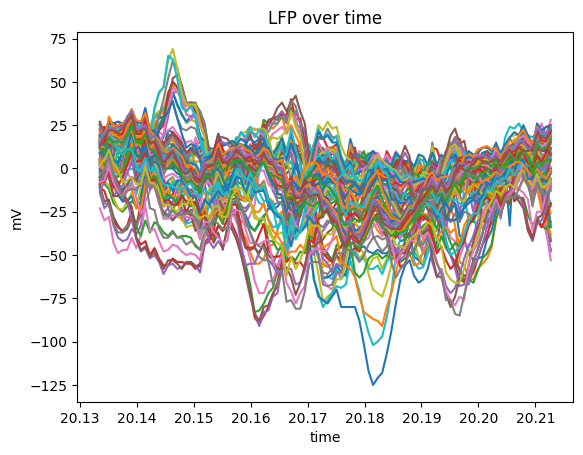

In [13]:
# conversion to np.array required for plotting
probeC_lfp_times = np.array(lfp["ElectricalSeriesProbeC-LFP"].timestamps)
probeC_lfp_traces = np.array(lfp["ElectricalSeriesProbeC-LFP"].data)

print(probeC_lfp_times.shape)
print(probeC_lfp_traces.shape)


plt.plot(probeC_lfp_times[:100], probeC_lfp_traces[:100])
plt.xlabel("time")
plt.ylabel("mV")
plt.title("LFP over time")
plt.show()

### Spike Sorted Units and Metrics

In [14]:
units_table = nwb.units
print(units_table.colnames)
units_table

# NOTE: to convert to pandas dataframe, you need to have pandas installed
# Uncomment the line below to get a pandas dataframe (it may take a lot of time and memory)
units_table_df = units_table.to_dataframe()

('spike_times', 'electrodes', 'waveform_mean', 'waveform_sd', 'unit_name', 'firing_range', 'estimated_x', 'isi_violations_count', 'drift_std', 'amplitude', 'l_ratio', 'sync_spike_4', 'amplitude_cutoff', 'nn_hit_rate', 'half_width', 'estimated_z', 'sync_spike_8', 'peak_trough_ratio', 'nn_miss_rate', 'estimated_y', 'sync_spike_2', 'repolarization_slope', 'ks_unit_id', 'drift_ptp', 'original_cluster_id', 'rp_violations', 'decoder_probability', 'velocity_below', 'd_prime', 'amplitude_cv_range', 'drift_mad', 'num_positive_peaks', 'device_name', 'amplitude_median', 'rp_contamination', 'snr', 'exp_decay', 'num_negative_peaks', 'peak_to_valley', 'recovery_slope', 'firing_rate', 'default_qc', 'spread', 'decoder_label', 'sliding_rp_violation', 'silhouette', 'isolation_distance', 'presence_ratio', 'amplitude_cv_median', 'extremum_channel_index', 'isi_violations_ratio', 'shank', 'velocity_above', 'num_spikes', 'depth')


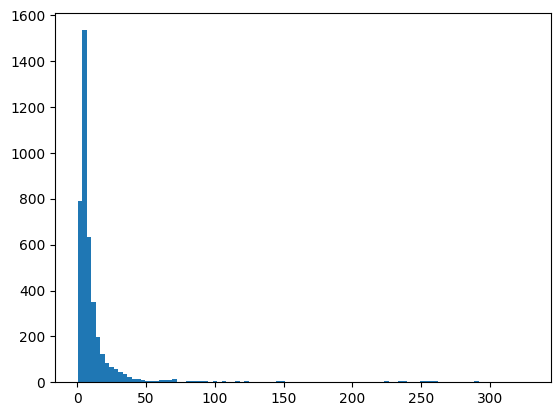

In [15]:
plt.hist(np.array(units_table["snr"]), bins=100)
plt.show()

In [16]:
# when indexing a pynwb table, make sure to access the row idx *after* accessing the column, as below
selected_units = [i for i in range(len(units_table)) if units_table["snr"][i] > 10]
# selected_units

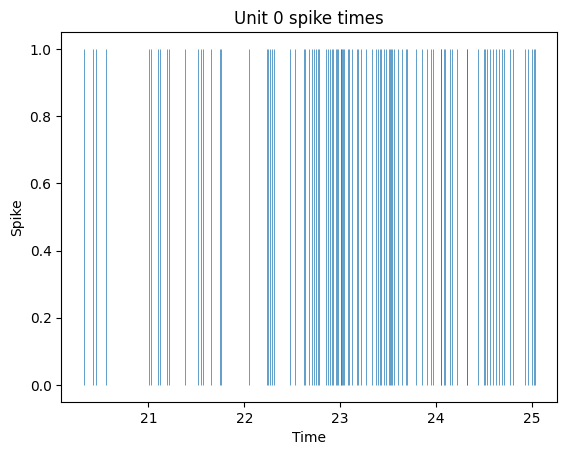

In [17]:
# conversion to np.array required for plotting
unit0_spikes = np.array(nwb.units["spike_times"][0])
plt.vlines(unit0_spikes[:100], 0, 1, lw=0.5)
plt.title("Unit 0 spike times")
plt.xlabel("Time")
plt.ylabel("Spike")
plt.show()

### Electrodes and Unit Brain Location
As of writing this, we *do not* have CCF locations packaged with our NWBs for this project, but for future NWB's the electrodes table will contain the location in the brain of each electrode. This table will be usable to get the location for each unit using the function `get_unit_location` below, which will include both the labeled brain region and the x,y,z coordinates.

In [18]:
electrodes = nwb.electrodes
electrodes
# use this to get pandas dataframe
# electrodes_df = electrodes.to_dataframe()
print(electrodes.colnames)
electrodes

('location', 'group', 'group_name', 'channel_name', 'gain_to_physical_unit', 'rel_y', 'physical_unit', 'inter_sample_shift', 'offset_to_physical_unit', 'rel_x')


,location,group,group_name,channel_name,gain_to_physical_unit,rel_y,physical_unit,inter_sample_shift,offset_to_physical_unit,rel_x
id,,,,,,,,,,
0,unknown,ProbeA pynwb.ecephys.ElectrodeGroup at 0x6273358560\nFields:\n description: Recorded electrodes from probe ProbeA\n device: ProbeA pynwb.device.Device at 0x6273359664\nFields:\n description: Model: - Serial number: 22175714801\n manufacturer: IMEC\n\n location: unknown\n,ProbeA,AP0,0.195,0.0,uV,0.000000,0.0,16.0
1,unknown,ProbeA pynwb.ecephys.ElectrodeGroup at 0x6273358560\nFields:\n description: Recorded electrodes from probe ProbeA\n device: ProbeA pynwb.device.Device at 0x6273359664\nFields:\n description: Model: - Serial number: 22175714801\n manufacturer: IMEC\n\n location: unknown\n,ProbeA,AP1,0.195,0.0,uV,0.000000,0.0,48.0
2,unknown,ProbeA pynwb.ecephys.ElectrodeGroup at 0x6273358560\nFields:\n description: Recorded electrodes from probe ProbeA\n device: ProbeA pynwb.device.Device at 0x6273359664\nFields:\n description: Model: - Serial number: 22175714801\n manufacturer: IMEC\n\n location: unknown\n,ProbeA,AP2,0.195,20.0,uV,0.076923,0.0,0.0
3,unknown,ProbeA pynwb.ecephys.ElectrodeGroup at 0x6273358560\nFields:\n description: Recorded electrodes from probe ProbeA\n device: ProbeA pynwb.device.Device at 0x6273359664\nFields:\n description: Model: - Serial number: 22175714801\n manufacturer: IMEC\n\n location: unknown\n,ProbeA,AP3,0.195,20.0,uV,0.076923,0.0,32.0


In [19]:
np.unique(nwb.electrodes['group_name'])

array(['ProbeA', 'ProbeB', 'ProbeC', 'ProbeD', 'ProbeE', 'ProbeF'],
      dtype='<U6')

In [20]:
# this will work once CCF info is packaged in the NWB
def get_unit_locations(units_table):
    unit_locations = []
    for unit_idx in range(len(units_table)):
        mean_waveforms = units_table['waveform_mean'][unit_idx]
        waveform_mins = np.min(mean_waveforms, axis=1)
        peak_channel_idx = np.argmin(waveform_mins)

        # gets a window into the electrodes table
        detected_electrodes = units_table['electrodes'][unit_idx]
        unit_location = detected_electrodes.iloc[peak_channel_idx].location
        unit_locations.append(unit_location)

    return unit_locations

### Running

1.  You can use 2 methods for accessing behavior like runnning <br>
    a.  processing['running'] <br>
    b. acquisition["raw_running_wheel_rotation"]

In [21]:
from pynwb import NWBHDF5IO

# Open the NWB file using a context manager
with NWBHDF5IO(filepath, 'r') as io:
    nwb = io.read()
    running_speed = nwb.processing['running']['running_speed']
    
    # --- Inspect structure while file is open ---
    print(running_speed)         # Text representation (safer than HTML)
    print(running_speed.fields)  # List all available fields
    
    # --- Load actual data into memory if you need it later ---
    data_array = running_speed.data[:] 
    timestamps = running_speed.timestamps[:]

running_speed pynwb.base.TimeSeries at 0x13522898992
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (259202,), type "<f8">
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamp_link: (
    running_wheel_rotation <class 'pynwb.base.TimeSeries'>
  )
  timestamps: <HDF5 dataset "timestamps": shape (259202,), type "<f8">
  timestamps_unit: seconds
  unit: cm/s

{'resolution': -1.0, 'comments': 'no comments', 'description': 'no description', 'conversion': 1.0, 'offset': 0.0, 'unit': 'cm/s', 'data': <HDF5 dataset "data": shape (259202,), type "<f8">, 'timestamps': <HDF5 dataset "timestamps": shape (259202,), type "<f8">, 'timestamps_unit': 'seconds', 'interval': 1, 'timestamp_link': [running_wheel_rotation pynwb.base.TimeSeries at 0x13522902592
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (259202,), type "<f4">
  description: no description
  interval: 1
  offset: 0.0
  resoluti

/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/Users/aryan/miniforge3/envs/nwbModern/lib/python3.10/site-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using

In [22]:
def compute_wheel_speed(nwb):
    print("  > Extracting wheel data...")
    try:
        # 1. Primary Path: Direct access
        if 'running' in nwb.processing:
            running_module = nwb.processing['running']
            
            # Try different access patterns
            if hasattr(running_module, 'data_interfaces') and 'running_speed' in running_module.data_interfaces:
                obj = running_module.data_interfaces['running_speed']
            elif hasattr(running_module, 'running_speed'):
                obj = running_module.running_speed
            else:
                obj = None
                
            if obj is not None:
                # Load data IMMEDIATELY while file is open
                data = obj.data[:]
                timestamps = obj.timestamps[:]
                return data, timestamps
        
        # 2. Fallback A: Standard 'behavior' module
        if 'behavior' in nwb.processing:
            behavior_module = nwb.processing['behavior']
            if hasattr(behavior_module, 'data_interfaces') and 'running_speed' in behavior_module.data_interfaces:
                obj = behavior_module.data_interfaces['running_speed']
                data = obj.data[:]
                timestamps = obj.timestamps[:]
                return data, timestamps
            
        # 3. Fallback B: Raw acquisition
        if 'raw_running_wheel_rotation' in nwb.acquisition:
            wheel_rot = nwb.acquisition['raw_running_wheel_rotation']
            raw_data = wheel_rot.data[:]
            timestamps = wheel_rot.timestamps[:]
            
            d_rot = np.diff(raw_data, prepend=raw_data[0])
            d_time = np.diff(timestamps, prepend=timestamps[0] - 0.01)
            d_time[d_time < 0.001] = 0.001
            
            speed = d_rot / d_time
            return speed, timestamps
        
        print("  ! No wheel data found.")
        return None, None
        
    except Exception as e:
        print(f"  ! Error processing wheel data: {e}")
        import traceback
        traceback.print_exc()
        return None, None


# Use it like this:
with NWBHDF5IO(filepath, 'r') as io:
    nwb = io.read()
    data, timestamps = compute_wheel_speed(nwb)  # Call INSIDE the with block
    
# Now you can use data and timestamps outside the with block
print(data.shape)
print(timestamps.shape)

  > Extracting wheel data...
(259202,)
(259202,)


### Eye Tracking

In [23]:
eye_tracking = nwb.processing['eye_tracking']
eye_tracking.keys()

dict_keys(['likely_blink_times', 'corneal_reflection', 'ellipse', 'pupil'])

In [24]:
pupil_tracking = eye_tracking["pupil"]
pupil_tracking.colnames

('reference_frame',
 'data_x',
 'data_y',
 'area',
 'area_raw',
 'width',
 'height',
 'angle',
 'timestamps')

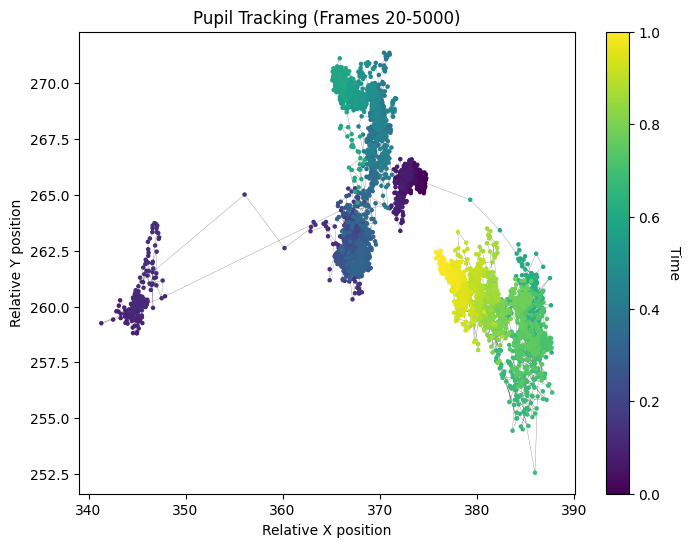

In [25]:
# NOTE: Most prabably you face error as the following code cell is not the best way to access NWB data

from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# 1. Refresh the connection to your local file
# Use the path we confirmed earlier
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"

with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # 2. Re-grab the interface while the file is explicitly open
    eye_mod = nwb.processing['eye_tracking']
    pupil_tracking = eye_mod.get_data_interface('pupil')
    
    # 3. Use the .data property to pull a clean slice into memory
    # We use .data[:] or .data[start:end] to force the 'load'
    start, end = 20, 5000
    xs = pupil_tracking['data_x'].data[start:end]
    ys = pupil_tracking['data_y'].data[start:end]

    # 4. Now the plotting logic will work because xs and ys are standard numpy arrays
    colors = mpl.cm.viridis(np.linspace(0, 1, len(xs)))
    plt.figure(figsize=(8, 6))
    plt.plot(xs, ys, zorder=0, linewidth=0.25, color='gray')
    sc = plt.scatter(xs, ys, s=5, c=colors, zorder=1)
    
    cbar = plt.colorbar(sc)
    cbar.ax.set_ylabel('Time', rotation=270, labelpad=15)
    plt.xlabel("Relative X position")
    plt.ylabel("Relative Y position")
    plt.title("Pupil Tracking (Frames 20-5000)")
    plt.show()

### Running Wheel

Success! Times shape: (5000,)
Success! Trace shape: (5000,)


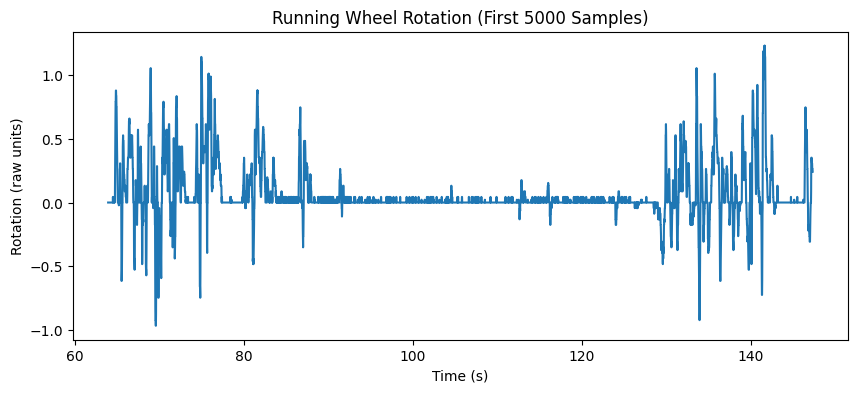

In [26]:
# NOTE: Most prabably you face error as the following code cell is not the best way to access NWB data

from pynwb import NWBHDF5IO
import numpy as np
import matplotlib.pyplot as plt

# Re-establish the file path confirmed for your machine
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"

# We use a 'with' statement to ensure the file handle stays active for the read
with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # Access the acquisition module
    wheel_rotation = nwb.acquisition["raw_running_wheel_rotation"]
    
    # Pull a manageable slice (e.g., first 5000 samples) to avoid memory errors
    start, end = 0, 5000
    wheel_times = wheel_rotation.timestamps[start:end]
    wheel_trace = wheel_rotation.data[start:end]

    print(f"Success! Times shape: {wheel_times.shape}")
    print(f"Success! Trace shape: {wheel_trace.shape}")

    # Plot to verify the movement data
    plt.figure(figsize=(10, 4))
    plt.plot(wheel_times, wheel_trace)
    plt.xlabel("Time (s)")
    plt.ylabel("Rotation (raw units)")
    plt.title("Running Wheel Rotation (First 5000 Samples)")
    plt.show()

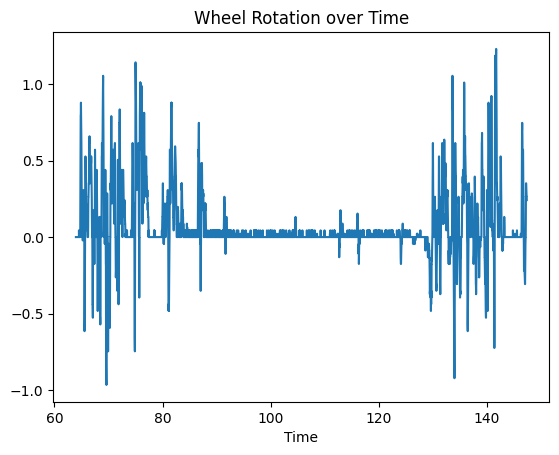

In [27]:
plt.plot(wheel_times,wheel_trace)
plt.title("Wheel Rotation over Time")
plt.xlabel("Time")
plt.show()

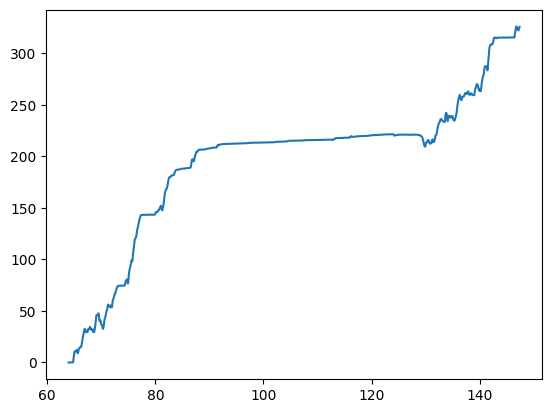

In [28]:
plt.plot(wheel_times, np.cumsum(wheel_trace))

# Alignments

No need for running previous cells for running alingment  <br>
* This average analysis applied on the raw data without any preprocessing on raw signal

# Generalized for different session types

**NOTE:** Change the file directory and the file name for saving pdf <br>
 

Opening /Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb...
  > Extracting wheel data...
  > Extracting pupil data...
  > Found experimental block: Sensory-motor mismatch block_presentations
Generating Session Info Page...
Generating Wheel Speed Page...
Generating Pupil Diameter Page...
Found Probes: ['ElectricalSeriesProbeA-LFP', 'ElectricalSeriesProbeB-LFP', 'ElectricalSeriesProbeC-LFP', 'ElectricalSeriesProbeD-LFP', 'ElectricalSeriesProbeE-LFP', 'ElectricalSeriesProbeF-LFP']
Processing LFP for ElectricalSeriesProbeA-LFP (ACA)...
Processing LFP for ElectricalSeriesProbeB-LFP (Vis a)...
Processing LFP for ElectricalSeriesProbeC-LFP (Vis p)...
Processing LFP for ElectricalSeriesProbeD-LFP (Vis lm)...
Processing LFP for ElectricalSeriesProbeE-LFP (MOp)...
Processing LFP for ElectricalSeriesProbeF-LFP (ACA MOs)...


KeyboardInterrupt: 

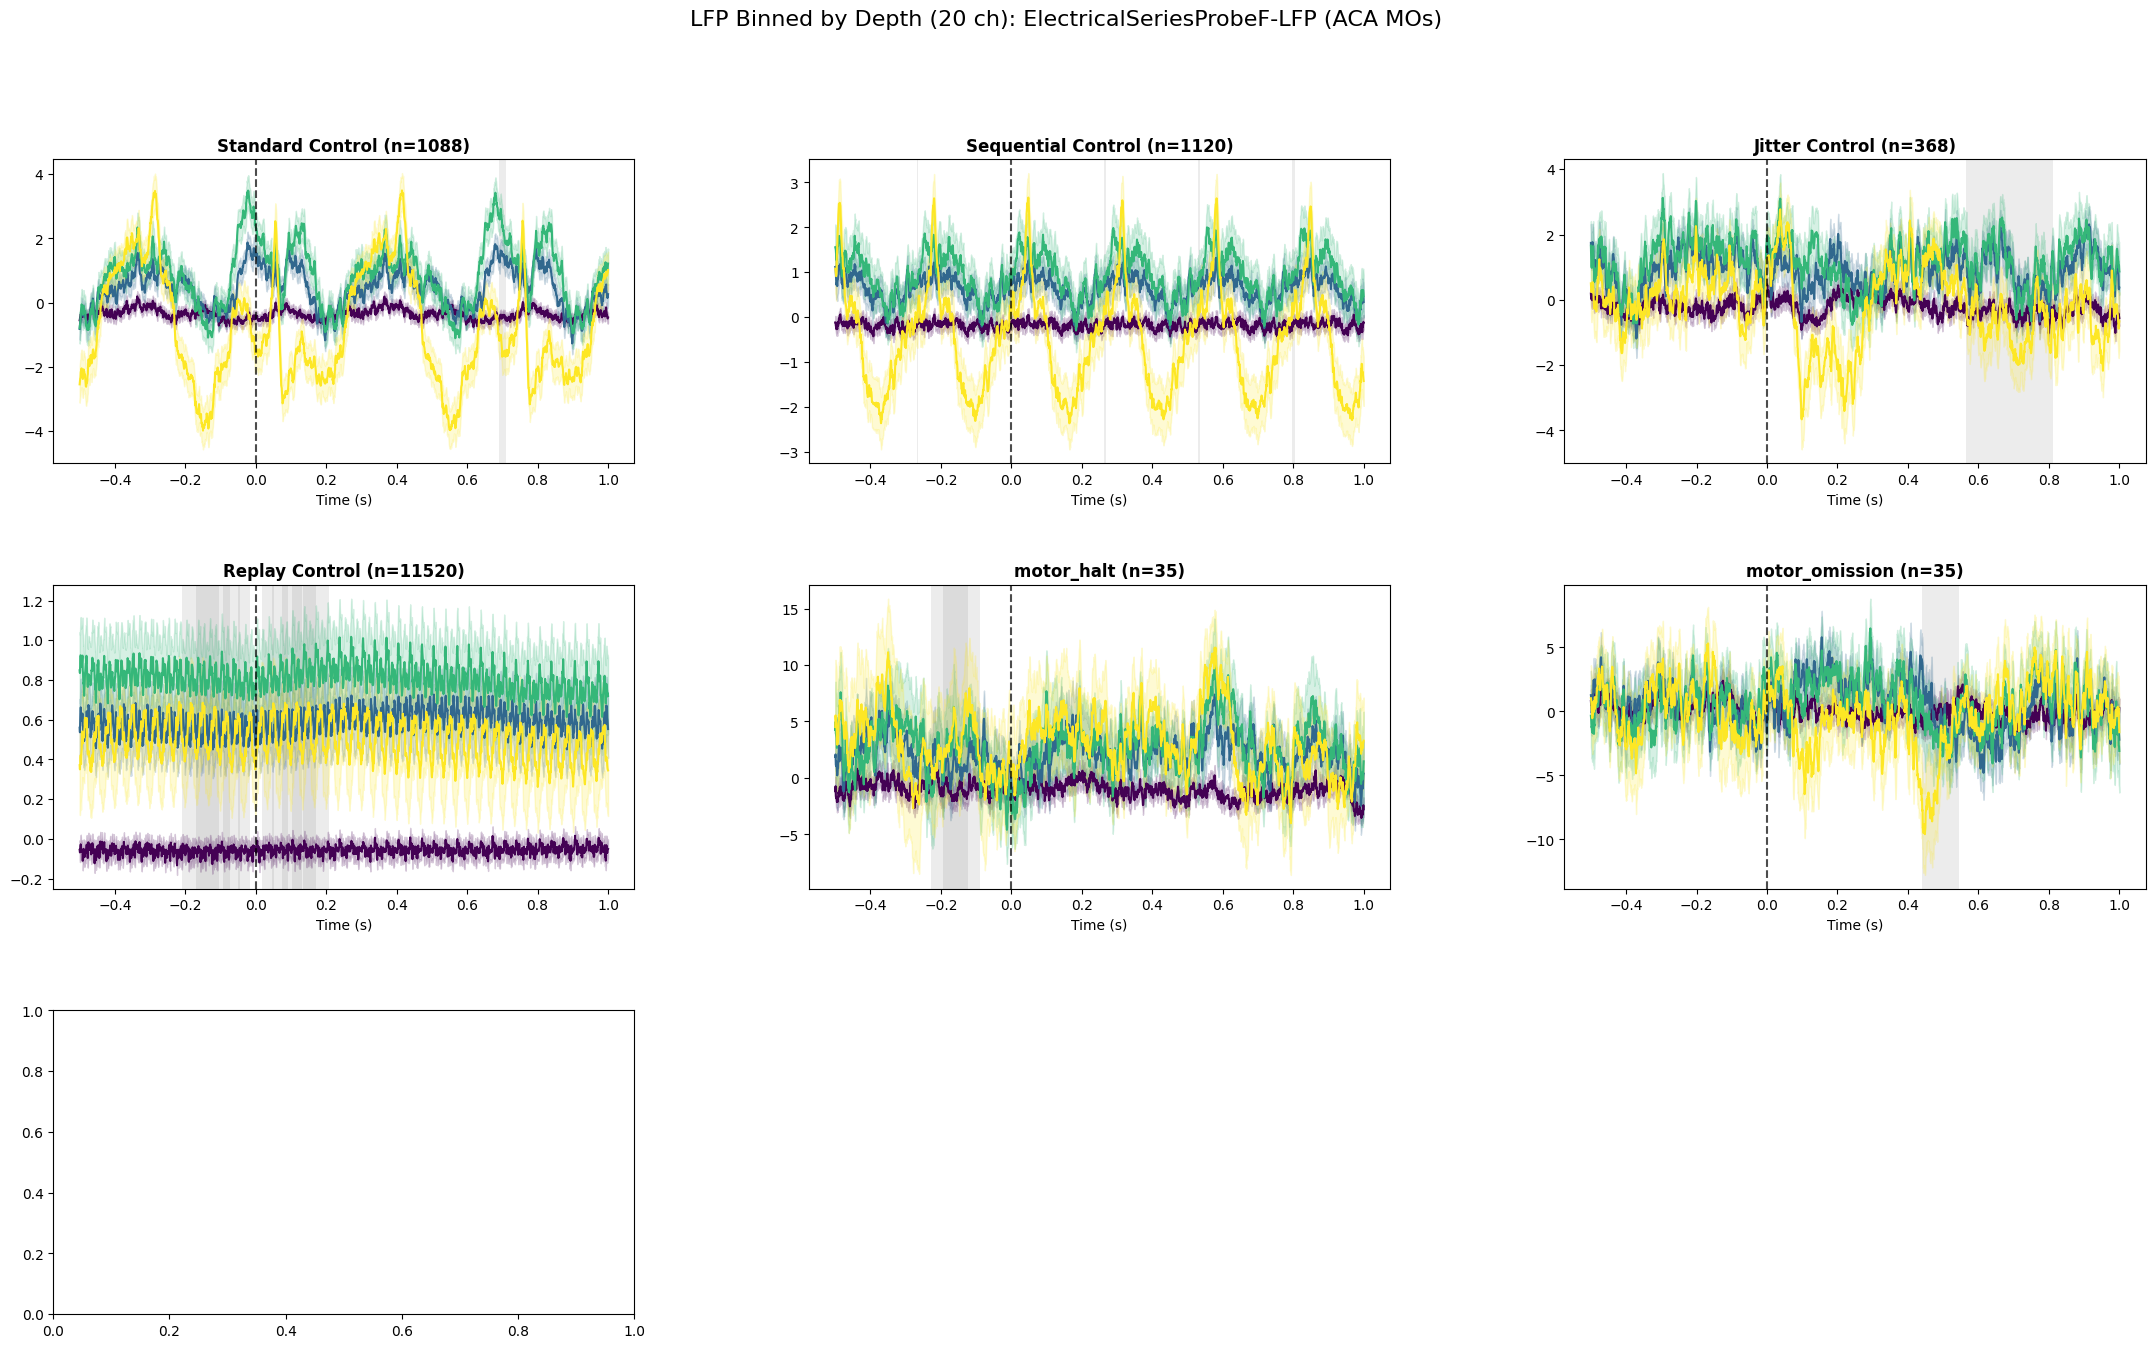

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
import warnings
from scipy import stats

# Suppress warnings
warnings.filterwarnings("ignore", module="hdmf")

# --- Configuration ---
# Update this path to your specific file
# # Sessions to choose from:
# # Sunject ID: 820459
#     # "sub-820459/sub-820459_ses-ecephys-820459-2025-11-12-14-34-33_ecephys.nwb"
#     # "sub-820459/sub-820459_ses-ecephys-820459-2025-11-10-15-07-13_ecephys.nwb"
# # Subject ID: 820454
#     # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-07-10-54-23_ecephys.nwb"
#     # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-06-16-00-27_ecephys.nwb"
#     # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-05-15-21-15_ecephys.nwb"
#     # "sub-820454/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"

nwb_file_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
output_pdf_name = 'alignment_report_820454-2025-11-04.pdf'
window_seconds = [-0.5, 1.0]
depth_bin_size = 20

# --- Mappings ---
REGION_MAP = {
    'ProbeA': 'ACA',
    'ProbeB': 'Vis a',
    'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm',
    'ProbeE': 'MOp',
    'ProbeF': 'ACA MOs'
}

CONTROL_NAMES = {
    1: "Standard Control",
    2: "Sequential Control",
    3: "Jitter Control",
    4: "Replay Control"
}

# --- Helper Functions ---

def determine_session_type(nwb):
    keys = list(nwb.intervals.keys())
    if "Sensory-motor mismatch block_presentations" in keys:
        return "Sensorimotor Mismatch"
    elif "Sequence mismatch block_presentations" in keys:
        return "Sequence Mismatch"
    elif "Duration mismatch block_presentations" in keys:
        return "Duration Mismatch"
    elif "Standard mismatch block_presentations" in keys:
        return "Standard Mismatch"
    else:
        if any("mismatch" in k.lower() for k in keys):
            return "Generic/Unknown Mismatch"
        return "Unknown Session Type"

def get_probe_region_name(nwb_probe_name):
    for key, region in REGION_MAP.items():
        if key.lower() in nwb_probe_name.lower():
            return region
    return "Unknown Region"

def get_aligned_traces(timestamps, data, data_timestamps, window):
    # Estimate sampling rate
    if len(data_timestamps) > 100:
        dt = np.median(np.diff(data_timestamps[:100]))
    else:
        dt = np.median(np.diff(data_timestamps))
    
    fs = 1.0 / dt
    samples_pre = int(abs(window[0]) * fs)
    samples_post = int(window[1] * fs)
    n_samples = samples_pre + samples_post
    
    aligned_data = []
    event_indices = np.searchsorted(data_timestamps, timestamps)
    
    for idx in event_indices:
        start_idx = idx - samples_pre
        end_idx = idx + samples_post
        
        if start_idx >= 0 and end_idx < data.shape[0]:
            aligned_data.append(data[start_idx:end_idx])
        else:
            shape = (n_samples, *data.shape[1:]) if data.ndim > 1 else (n_samples,)
            aligned_data.append(np.full(shape, np.nan))
            
    t_vec = np.linspace(window[0], window[1], n_samples)
    return np.array(aligned_data), t_vec

def bin_depth_data(lfp_aligned, bin_size):
    n_trials, n_samples, n_channels = lfp_aligned.shape
    n_bins = n_channels // bin_size
    
    binned_mean = np.zeros((n_samples, n_bins))
    binned_sem = np.zeros((n_samples, n_bins))
    bin_centers = np.zeros(n_bins)
    
    for i in range(n_bins):
        start_ch = i * bin_size
        end_ch = min((i + 1) * bin_size, n_channels)
        bin_centers[i] = (start_ch + end_ch) / 2
        
        bin_data = lfp_aligned[:, :, start_ch:end_ch]
        binned_mean[:, i] = np.nanmean(bin_data, axis=(0, 2))
        binned_sem[:, i] = stats.sem(np.nanmean(bin_data, axis=2), axis=0, nan_policy='omit')
    
    return binned_mean, binned_sem, bin_centers

def overlay_stimulus_intervals(ax, target_start_times, all_block_times, window):
    """
    Calculates the timing of neighbor stimuli (rank -1, +1, +2, etc.)
    relative to the target trials and plots a shaded box (Mean +/- Std).
    """
    # 1. Identify indices of our target trials within the master list of all stimuli
    # We assume target_start_times is a subset of all_block_times
    all_block_times = np.sort(all_block_times)
    
    # Using searchsorted to find where our targets fit in the master list
    target_indices = np.searchsorted(all_block_times, target_start_times)
    
    # 2. Iterate through "ranks" (neighbors). 
    # Rank +1 = immediate next stim, Rank -1 = immediate prev stim
    # We check a reasonable range of neighbors (e.g. -5 to +5) to see what fits in window
    neighbor_ranks = range(-5, 6) 
    
    for rank in neighbor_ranks:
        if rank == 0: continue # Skip the alignment event itself (t=0)
        
        # Find indices of the neighbors
        neighbor_indices = target_indices + rank
        
        # Filter out indices that are out of bounds (start or end of session)
        valid_mask = (neighbor_indices >= 0) & (neighbor_indices < len(all_block_times))
        
        if not np.any(valid_mask):
            continue
            
        # Get the timestamps
        valid_targets = target_start_times[valid_mask]
        valid_neighbors = all_block_times[neighbor_indices[valid_mask]]
        
        # Calculate relative time (latency)
        latencies = valid_neighbors - valid_targets
        
        # Filter latencies that actually fall into our plot window
        window_mask = (latencies >= window[0]) & (latencies <= window[1])
        final_latencies = latencies[window_mask]
        
        if len(final_latencies) > 0:
            mean_lat = np.mean(final_latencies)
            # Using Standard Deviation to visualize the jitter/distribution range
            # (SEM would be too narrow to see for large N)
            std_lat = np.std(final_latencies)
            
            # Draw the shaded box
            ax.axvspan(mean_lat - std_lat, mean_lat + std_lat, 
                       color='gray', alpha=0.15, zorder=0, linewidth=0)
            
            # Optional: Add a small text label for the mean rank if needed
            # ax.text(mean_lat, ax.get_ylim()[1], f"S{rank:+}", ha='center', fontsize=6, color='gray')

# --- Data Extraction ---

def compute_wheel_speed(nwb):
    print("  > Extracting wheel data...")
    try:
        if 'running' in nwb.processing:
            running_module = nwb.processing['running']
            if hasattr(running_module, 'data_interfaces') and 'running_speed' in running_module.data_interfaces:
                obj = running_module.data_interfaces['running_speed']
            elif hasattr(running_module, 'running_speed'):
                obj = running_module.running_speed
            else:
                obj = None
            if obj is not None:
                return obj.data[:], obj.timestamps[:]
        
        if 'behavior' in nwb.processing:
            behavior_module = nwb.processing['behavior']
            if hasattr(behavior_module, 'data_interfaces') and 'running_speed' in behavior_module.data_interfaces:
                obj = behavior_module.data_interfaces['running_speed']
                return obj.data[:], obj.timestamps[:]
            
        if 'raw_running_wheel_rotation' in nwb.acquisition:
            wheel_rot = nwb.acquisition['raw_running_wheel_rotation']
            raw_data = wheel_rot.data[:]
            timestamps = wheel_rot.timestamps[:]
            d_rot = np.diff(raw_data, prepend=raw_data[0])
            d_time = np.diff(timestamps, prepend=timestamps[0] - 0.01)
            d_time[d_time < 0.001] = 0.001
            speed = d_rot / d_time
            return speed, timestamps
        
        return None, None
    except Exception:
        return None, None

def compute_pupil_data(nwb):
    print("  > Extracting pupil data...")
    try:
        if 'eye_tracking' in nwb.processing:
            eye_tracking_module = nwb.processing['eye_tracking']
            if hasattr(eye_tracking_module, 'data_interfaces') and 'pupil' in eye_tracking_module.data_interfaces:
                pupil_table = eye_tracking_module.data_interfaces['pupil']
            elif hasattr(eye_tracking_module, 'pupil'):
                pupil_table = eye_tracking_module.pupil
            else:
                return None, None
            
            width_data = pupil_table['width'].data[:]
            if 'timestamps' in pupil_table.colnames:
                timestamps = pupil_table['timestamps'].data[:]
            elif hasattr(pupil_table, 'timestamps'):
                if hasattr(pupil_table.timestamps, 'data'):
                    timestamps = pupil_table.timestamps.data[:]
                else:
                    timestamps = pupil_table.timestamps[:]
            else:
                return None, None

            return width_data, timestamps
        else:
            return None, None
    except Exception:
        return None, None

def get_analysis_conditions(nwb):
    conditions = []
    
    # 1. Map Standard Controls
    for i in range(1, 5):
        key_partial = f"Control block {i}"
        matches = [k for k in nwb.intervals.keys() if key_partial in k]
        if matches:
            conditions.append({
                'title': CONTROL_NAMES[i],
                'table_key': matches[0],
                'filter_col': None,
                'filter_val': None
            })
            
    # 2. Map Mismatch Blocks
    target_tables = [
        "Sensory-motor mismatch block_presentations",
        "Sequence mismatch block_presentations",
        "Duration mismatch block_presentations",
        "Standard mismatch block_presentations"
    ]
    
    found_key = None
    for target in target_tables:
        if target in nwb.intervals:
            found_key = target
            break
            
    if not found_key:
        possible_matches = [k for k in nwb.intervals.keys() if "mismatch" in k.lower() and "block" in k.lower()]
        if possible_matches:
            found_key = possible_matches[0]

    if found_key:
        print(f"  > Found experimental block: {found_key}")
        mm_table = nwb.intervals[found_key].to_dataframe()
        
        potential_cols = ['stimulus_condition', 'trial_type', 'TrialType', 'condition']
        type_col = None
        for col in potential_cols:
            if col in mm_table.columns:
                type_col = col
                break
        
        if type_col:
            unique_types = mm_table[type_col].dropna().astype(str).unique()
            unique_types.sort()
            
            for u_type in unique_types:
                conditions.append({
                    'title': str(u_type), 
                    'table_key': found_key,
                    'filter_col': type_col,
                    'filter_val': u_type
                })
        else:
            conditions.append({'title': "Mismatch Block (All)", 'table_key': found_key, 'filter_col': None})
            
    return conditions

# --- Plotting Functions ---
def plot_session_info(pdf, nwb, nwb_file_path):
    """Plots a text summary page with session and subject information."""
    print("Generating Session Info Page...")
    fig = plt.figure(figsize=(10, 10))
    plt.axis('off')
    
    # --- Extract Session Info ---
    sess_type = determine_session_type(nwb)
    sess_id = nwb.session_id if nwb.session_id else "Unknown"
    desc = nwb.session_description if nwb.session_description else "No description"
    sess_start = nwb.session_start_time if hasattr(nwb, 'session_start_time') else "Unknown"
    
    # --- Extract Subject Info ---
    if nwb.subject:
        subj_id = nwb.subject.subject_id if hasattr(nwb.subject, 'subject_id') else "Unknown"
        age = nwb.subject.age if hasattr(nwb.subject, 'age') else "Unknown"
        sex = nwb.subject.sex if hasattr(nwb.subject, 'sex') else "Unknown"
        species = nwb.subject.species if hasattr(nwb.subject, 'species') else "Unknown"
        genotype = nwb.subject.genotype if hasattr(nwb.subject, 'genotype') else "Unknown"
        dob = nwb.subject.date_of_birth if hasattr(nwb.subject, 'date_of_birth') else "Unknown"
    else:
        subj_id = age = sex = species = genotype = dob = "Unknown"
    
    # --- Format Info Text ---
    info_text = (
        f"SESSION ANALYSIS REPORT\n"
        f"{'=' * 50}\n\n"
        f"SESSION INFORMATION\n"
        f"{'-' * 50}\n"
        f"Session ID        : {sess_id}\n"
        f"Session Type      : {sess_type}\n"
        f"Session Start     : {sess_start}\n"
        f"Description       : {desc}\n\n"
        f"SUBJECT INFORMATION\n"
        f"{'-' * 50}\n"
        f"Subject ID        : {subj_id}\n"
        f"Species           : {species}\n"
        f"Sex               : {sex}\n"
        f"Age               : {age}\n"
        f"Date of Birth     : {dob}\n"
        f"Genotype          : {genotype}\n\n"
        f"FILE INFORMATION\n"
        f"{'-' * 50}\n"
    )
    
    plt.text(0.05, 0.95, info_text, fontsize=11, family='monospace', 
             verticalalignment='top', horizontalalignment='left')
    
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

def plot_behavior_traces(pdf, nwb, data, timestamps, conditions, title_prefix, ylabel, color):
    if data is None: return

    print(f"Generating {title_prefix} Page...")
    n_plots = len(conditions)
    if n_plots == 0: return

    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(27, 5 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.4, wspace=0.3)
    fig.suptitle(f"{title_prefix} Traces", fontsize=16, y=0.98)
    
    for idx, cond in enumerate(conditions):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # 1. Get Dataframe for this block/condition
        df_full = nwb.intervals[cond['table_key']].to_dataframe()
        all_block_times = df_full['start_time'].values # Master list for relative timing
        
        # 2. Filter for specific trial type
        if cond['filter_col']:
            val_to_match = str(cond['filter_val'])
            mask = df_full[cond['filter_col']].astype(str) == val_to_match
            subset = df_full[mask]
            start_times = subset['start_time'].values
        else:
            start_times = df_full['start_time'].values
            
        if len(start_times) == 0:
            ax.text(0.5, 0.5, "No Events", ha='center', va='center')
            ax.set_title(f"{cond['title']} (n=0)")
            ax.grid(False) # GRID OFF
            continue
        
        # 3. Align Data
        aligned, t_vec = get_aligned_traces(start_times, data, timestamps, window_seconds)
        mean_trace = np.nanmean(aligned, axis=0)
        sem_trace = stats.sem(aligned, axis=0, nan_policy='omit')
        
        # 4. Plot Overlay (Stimulus Distributions)
        overlay_stimulus_intervals(ax, start_times, all_block_times, window_seconds)
        
        # 5. Plot Main Data
        ax.plot(t_vec, mean_trace, color=color, linewidth=2.5, label='Mean')
        ax.fill_between(t_vec, mean_trace - sem_trace, mean_trace + sem_trace,
                        color=color, alpha=0.3, label='SEM')
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.set_title(f"{cond['title']} (n={len(start_times)})", fontsize=12, fontweight='bold')
        ax.set_xlabel("Time from stim onset (s)", fontsize=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        
        ax.grid(False) # GRID OFF

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

def process_probe_lfp(pdf, nwb, probe_name, conditions):
    region_name = get_probe_region_name(probe_name)
    display_title = f"{probe_name} ({region_name})"
    
    print(f"Processing LFP for {display_title}...")
    
    try:
        lfp_interface = nwb.processing['ecephys']['LFP'].electrical_series[probe_name]
        lfp_data = lfp_interface.data 
        lfp_ts = lfp_interface.timestamps[:] 
    except KeyError:
        return

    n_plots = len(conditions)
    if n_plots == 0: return

    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    # --- HEATMAPS ---
    fig1 = plt.figure(figsize=(18, 5 * n_rows))
    gs1 = gridspec.GridSpec(n_rows, n_cols, figure=fig1, hspace=0.4, wspace=0.3)
    fig1.suptitle(f"LFP Heatmaps: {display_title}", fontsize=16, y=0.98)
    
    for idx, cond in enumerate(conditions):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig1.add_subplot(gs1[row, col])
        
        df_full = nwb.intervals[cond['table_key']].to_dataframe()
        # Note: We don't overlay shaded boxes on heatmaps usually as it obscures data
        
        if cond['filter_col']:
            val_to_match = str(cond['filter_val'])
            mask = df_full[cond['filter_col']].astype(str) == val_to_match
            subset = df_full[mask]
            start_times = subset['start_time'].values
        else:
            start_times = df_full['start_time'].values
            
        if len(start_times) == 0:
            ax.text(0.5, 0.5, "No Events", ha='center', va='center')
            ax.grid(False)
            continue
            
        lfp_aligned, t_vec_lfp = get_aligned_traces(start_times, lfp_data, lfp_ts, window_seconds)
        lfp_mean = np.nanmean(lfp_aligned, axis=0)
        
        im = ax.imshow(lfp_mean.T, aspect='auto', origin='lower',
                       extent=[t_vec_lfp[0], t_vec_lfp[-1], 0, lfp_mean.shape[1]],
                       cmap='seismic', vmin=-0.00015, vmax=0.00015)
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.set_title(f"{cond['title']} (n={len(start_times)})", fontsize=12, fontweight='bold')
        ax.set_xlabel("Time (s)", fontsize=10)
        if col == 0:
            ax.set_ylabel("Channel", fontsize=10)
        ax.grid(False) # GRID OFF
    
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close(fig1)
    
    # --- BINNED TRACES ---
    fig2 = plt.figure(figsize=(27, 5 * n_rows))
    gs2 = gridspec.GridSpec(n_rows, n_cols, figure=fig2, hspace=0.4, wspace=0.3)
    fig2.suptitle(f"LFP Binned by Depth ({depth_bin_size} ch): {display_title}", fontsize=16, y=0.98)
    
    for idx, cond in enumerate(conditions):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig2.add_subplot(gs2[row, col])
        
        df_full = nwb.intervals[cond['table_key']].to_dataframe()
        all_block_times = df_full['start_time'].values

        if cond['filter_col']:
            val_to_match = str(cond['filter_val'])
            mask = df_full[cond['filter_col']].astype(str) == val_to_match
            subset = df_full[mask]
            start_times = subset['start_time'].values
        else:
            start_times = df_full['start_time'].values
            
        if len(start_times) == 0:
            ax.text(0.5, 0.5, "No Events", ha='center', va='center')
            ax.grid(False)
            continue
        
        lfp_aligned, t_vec_lfp = get_aligned_traces(start_times, lfp_data, lfp_ts, window_seconds)
        binned_mean, binned_sem, bin_centers = bin_depth_data(lfp_aligned, depth_bin_size)
        
        # Overlay Stimulus Timing Stats
        overlay_stimulus_intervals(ax, start_times, all_block_times, window_seconds)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(bin_centers)))
        for i, (bin_center, color) in enumerate(zip(bin_centers, colors)):
            mean_trace = binned_mean[:, i]
            sem_trace = binned_sem[:, i]
            offset = i * 0.0001
            
            ax.plot(t_vec_lfp, mean_trace + offset, color=color, linewidth=1.5)
            ax.fill_between(t_vec_lfp, 
                            mean_trace + offset - sem_trace,
                            mean_trace + offset + sem_trace,
                            color=color, alpha=0.2)
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.set_title(f"{cond['title']} (n={len(start_times)})", fontsize=12, fontweight='bold')
        ax.set_xlabel("Time (s)", fontsize=10)
        ax.grid(False) # GRID OFF
    
    pdf.savefig(fig2, bbox_inches='tight')
    plt.close(fig2)

# --- Main Execution ---

if __name__ == "__main__":
    try:
        print(f"Opening {nwb_file_path}...")
        with NWBHDF5IO(nwb_file_path, 'r') as io:
            nwb = io.read()
            
            wheel_speed, wheel_ts = compute_wheel_speed(nwb)
            pupil_data, pupil_ts = compute_pupil_data(nwb)
            conditions = get_analysis_conditions(nwb)
            
            if conditions:
                with PdfPages(output_pdf_name) as pdf:
                    plot_session_info(pdf, nwb, nwb_file_path)
                    
                    plot_behavior_traces(pdf, nwb, wheel_speed, wheel_ts, conditions, 
                                         "Wheel Speed", "Speed (cm/s)", '#2E7D32')

                    if pupil_data is not None:
                         plot_behavior_traces(pdf, nwb, pupil_data, pupil_ts, conditions, 
                                              "Pupil Diameter", "Width (px)", '#D81B60')
                    
                    if 'ecephys' in nwb.processing and 'LFP' in nwb.processing['ecephys'].data_interfaces:
                        probes = list(nwb.processing['ecephys']['LFP'].electrical_series.keys())
                        print(f"Found Probes: {probes}")
                        probes.sort()
                        for probe in probes:
                            process_probe_lfp(pdf, nwb, probe, conditions)
                    else:
                        print("Error: No LFP module found.")
                        
                print(f"\nAnalysis Complete! Saved to: {output_pdf_name}")
            else:
                print("! No conditions found.")

    except Exception as e:
        import traceback
        traceback.print_exc()
        print("\nFAILED.")

# Preprocessing 

## 1️⃣ Line Noise Removal (60 Hz Notch Filter)

### What is line noise?
LFP recordings often contain sinusoidal interference from electrical power systems:
- 60 Hz (US)

This noise appears as a sharp peak in the power spectrum and is **not neural**.

### Why use a notch filter?
A notch (band-stop) filter removes a **very narrow frequency band** centered at the power-line frequency while preserving:
- Gamma-band activity
- Spike-related LFP structure
- Broadband neural signals

* NOTE: Zero-Phase Filtering with `signal.filtfilt`

In [ ]:
from scipy import signal

def remove_line_noise(lfp_data, fs, freq=60, Q=30):
    """Remove 60Hz line noise and harmonics"""
    # Remove fundamental and harmonics (60, 120, 180 Hz)
    for harmonic in [freq, freq*2, freq*3]:
        if harmonic < fs/2:  # Below Nyquist
            # iirnotch filter
            b, a = signal.iirnotch(harmonic, Q, fs)
            lfp_data = signal.filtfilt(b, a, lfp_data, axis=0)
    return lfp_data

## 2️⃣ High-Pass Filtering to Remove Slow Drift
### Why choose a Butterworth filter?
Butterworth filters have:
- Maximally flat passband
- No ripple in frequency response
- Smooth and stable behavior

### Practical advantages for LFPs
- Minimal distortion of neural frequencies
- No artificial oscillations (ringing)
- Well-suited for continuous signals

In [ ]:
def highpass_filter(lfp_data, fs, cutoff=0.5, order=4):
    """
    Remove very slow drifts while preserving LFP frequencies
    0.5 Hz is conservative - keeps delta band (1-4 Hz)
    """
    nyq = fs / 2
    b, a = signal.butter(order, cutoff/nyq, btype='high')
    return signal.filtfilt(b, a, lfp_data, axis=0)

## 3️⃣ Common Average Referencing (CAR)

### What problem does CAR solve?
Many artifacts are global across channels:
- Motion Reference noise
- environmental interference
- These signals are shared and non-neural.

In [ ]:
# NOTE: Skip this preprocessing step if you are intressed in common information among the channels

def apply_car(lfp_data, bad_channels=None):
    """
    Subtract common average across channels
    Removes global artifacts while preserving local signals
    """
    if bad_channels is not None:
        good_channels = np.setdiff1d(np.arange(lfp_data.shape[1]), bad_channels)
        reference = np.median(lfp_data[:, good_channels], axis=1, keepdims=True)
    else:
        reference = np.median(lfp_data, axis=1, keepdims=True)
    
    return lfp_data - reference

## 4️⃣ Artifact Detection Using Z-Scores
### Why use z-score based detection?
Artifacts produce extreme, non-physiological amplitudes.
#### Threshold choice:
- 5σ is conservative
- Minimizes false positives
- Targets only extreme contamination

#### Two-level rejection
- Bad channels: unreliable electrodes
- Bad time points: global artifacts (movement, shock, etc.)

In [ ]:
def detect_artifacts(lfp_data, threshold=5):
    """
    Flag time points or channels with extreme values
    threshold = number of standard deviations
    """
    z_scores = np.abs(stats.zscore(lfp_data, axis=0))
    artifact_mask = z_scores > threshold
    
    # Bad channels: >10% of timepoints are artifacts
    bad_channels = np.where(np.mean(artifact_mask, axis=0) > 0.1)[0]
    
    # Bad time segments: >50% of channels are artifacts
    bad_times = np.where(np.mean(artifact_mask, axis=1) > 0.5)[0]
    
    return bad_channels, bad_times

### Pipline

In [ ]:
def preprocess_lfp(lfp_data, timestamps, fs=None):
    """
    Full preprocessing pipeline
    """
    # Estimate sampling rate if not provided
    if fs is None:
        fs = 1.0 / np.median(np.diff(timestamps))
    
    print(f"Sampling rate: {fs:.2f} Hz")
    
    # 1. Remove line noise (60 Hz + harmonics)
    print("Removing line noise...")
    lfp_clean = remove_line_noise(lfp_data, fs, freq=60, Q=30)
    
    # 2. High-pass filter (remove slow drift)
    print("Applying high-pass filter (0.5 Hz)...")
    lfp_clean = highpass_filter(lfp_clean, fs, cutoff=0.5)
    
    # 3. Detect artifacts before CAR
    print("Detecting artifacts...")
    bad_channels, bad_times = detect_artifacts(lfp_clean, threshold=5)
    print(f"  Bad channels: {len(bad_channels)}")
    print(f"  Bad time segments: {len(bad_times)}")
    
    # 4. Apply Common Average Reference
    print("Applying common average reference...")
    lfp_clean = apply_car(lfp_clean, bad_channels=bad_channels)
    
    # 5. Optional: Low-pass filter if you want to limit bandwidth
    # Typically not needed for LFP (usually pre-filtered during acquisition)
    
    return lfp_clean, bad_channels, bad_times

In [ ]:
def process_probe_lfp(pdf, nwb, probe_name, conditions):
    region_name = get_probe_region_name(probe_name)
    display_title = f"{probe_name} ({region_name})"
    
    print(f"Processing LFP for {display_title}...")
    
    try:
        lfp_interface = nwb.processing['ecephys']['LFP'].electrical_series[probe_name]
        lfp_data_raw = lfp_interface.data[:] 
        lfp_ts = lfp_interface.timestamps[:] 
        
        # NEW: Preprocess LFP
        print("  Preprocessing LFP data...")
        lfp_data, bad_channels, bad_times = preprocess_lfp(lfp_data_raw, lfp_ts)
        
        # Store info about bad channels for later reference
        if len(bad_channels) > 0:
            print(f"  Excluding {len(bad_channels)} noisy channels from analysis")
            
    except KeyError:
        return


This code for checking the effect of preprocesing

In [ ]:
from pynwb import NWBHDF5IO
import pandas as pd

# Use the path we confirmed earlier
nwb_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"

with NWBHDF5IO(nwb_path, mode='r', load_namespaces=True) as io:
    nwb = io.read()
    
    # Extract the electrode metadata
    electrodes_df = nwb.electrodes.to_dataframe()
    
    # This summarizes which probe is in which brain area
    region_summary = electrodes_df[['group_name', 'location']].drop_duplicates()
    
    print("PROBE TO REGION MAPPING FOUND IN FILE:")
    print(region_summary)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from pynwb import NWBHDF5IO
import warnings
import os

warnings.filterwarnings("ignore", module="hdmf")

# --- Configuration ---
nwb_file_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
channel_to_plot = 50  
time_window = [100, 110] 

# --- Region Mapping for better filenames ---
REGION_MAP = {
    'ProbeA': 'ACA',
    'ProbeB': 'Vis_a',
    'ProbeC': 'Vis_p',
    'ProbeD': 'Vis_lm',
    'ProbeE': 'MOp',
    'ProbeF': 'ACA_MOs'
}

# --- Helper Functions ---

def compute_psd(data, fs, nperseg=None):
    if nperseg is None:
        nperseg = min(int(fs * 2), len(data))
    freqs, psd = signal.welch(data, fs=fs, nperseg=nperseg, 
                               noverlap=nperseg//2, scaling='density')
    return freqs, psd

# Ensure these functions from your previous cells are defined:
# remove_line_noise, highpass_filter, detect_artifacts, apply_car

# --- Main Analysis Loop ---

print(f"Opening {nwb_file_path}...")

with NWBHDF5IO(nwb_file_path, 'r') as io:
    nwb = io.read()
    
    # 1. Automatically find all LFP probes
    try:
        all_probes = list(nwb.processing['ecephys']['LFP'].electrical_series.keys())
        print(f"Found {len(all_probes)} probes to process: {all_probes}")
    except KeyError:
        print("Error: No LFP processing module found.")
        all_probes = []

    for probe_key in all_probes:
        # Determine region name for cleaner output
        region = "Unknown"
        for k, v in REGION_MAP.items():
            if k.lower() in probe_key.lower():
                region = v
                break
        
        print(f"\n>>> Processing {probe_key} ({region})")
        
        try:
            lfp_interface = nwb.processing['ecephys']['LFP'].electrical_series[probe_key]
            lfp_ts = lfp_interface.timestamps[:]
            fs = 1.0 / np.median(np.diff(lfp_ts[:1000]))
            
            # Extract time window
            time_mask = (lfp_ts >= time_window[0]) & (lfp_ts <= time_window[1])
            time_indices = np.where(time_mask)[0]
            lfp_segment = lfp_interface.data[time_indices[0]:time_indices[-1]+1, :]
            ts_segment = lfp_ts[time_indices]
            
            # Preprocessing (Calling your existing functions)
            lfp_no_line = remove_line_noise(lfp_segment, fs, freq=60)
            lfp_highpass = highpass_filter(lfp_no_line, fs, cutoff=0.5)
            bad_channels, bad_times = detect_artifacts(lfp_highpass, threshold=5)
            lfp_full = apply_car(lfp_highpass, bad_channels=bad_channels)
            
            # --- Figure 1: Time Domain ---
            fig1, axes = plt.subplots(5, 1, figsize=(14, 12))
            fig1.suptitle(f'Preprocessing - {region}, Ch {channel_to_plot}', fontsize=14, fontweight='bold')
            time_vec = ts_segment - ts_segment[0]
            axes[0].plot(time_vec, lfp_segment[:, channel_to_plot], 'k', linewidth=0.5)
            axes[0].set_title('Raw LFP')
            axes[3].plot(time_vec, lfp_full[:, channel_to_plot], 'r', linewidth=0.5)
            axes[3].set_title('After CAR')
            axes[4].plot(time_vec, lfp_segment[:, channel_to_plot], 'k', alpha=0.3, label='Raw')
            axes[4].plot(time_vec, lfp_full[:, channel_to_plot], 'r', alpha=0.8, label='Preprocessed')
            axes[4].legend()
            plt.tight_layout()
            plt.savefig(f'QC_{region}_time_domain.png', dpi=150)
            
            # --- Figure 2: Frequency Domain (PSD) ---
            fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
            freqs_raw, psd_raw = compute_psd(lfp_segment[:, channel_to_plot], fs)
            freqs_full, psd_full = compute_psd(lfp_full[:, channel_to_plot], fs)
            axes[0].semilogy(freqs_raw, psd_raw, 'k', label='Raw')
            axes[0].semilogy(freqs_full, psd_full, 'r', label='Preprocessed')
            axes[0].set_title(f'PSD - {region}')
            axes[0].set_xlim([0, 150])
            axes[1].semilogy(freqs_raw, psd_raw, 'k')
            axes[1].semilogy(freqs_full, psd_full, 'r')
            axes[1].set_xlim([1, 100])
            axes[1].set_title('LFP Range (1-100Hz)')
            plt.savefig(f'QC_{region}_frequency_domain.png', dpi=150)

            # --- Figure 3: Spatial Profile ---
            fig3, axes = plt.subplots(1, 2, figsize=(14, 8))
            snapshot_idx = len(time_indices) // 2
            axes[0].plot(lfp_segment[snapshot_idx, :], np.arange(lfp_segment.shape[1]), 'k')
            axes[0].set_title('Raw Spatial Profile')
            axes[0].invert_yaxis()
            axes[1].plot(lfp_full[snapshot_idx, :], np.arange(lfp_full.shape[1]), 'r')
            axes[1].set_title('Preprocessed Spatial Profile')
            axes[1].invert_yaxis()
            plt.savefig(f'QC_{region}_spatial_profile.png', dpi=150)

            # --- Figure 4: Statistics ---
            fig4, axes = plt.subplots(1, 2, figsize=(12, 5))
            std_raw = np.std(lfp_segment, axis=0)
            std_full = np.std(lfp_full, axis=0)
            axes[0].plot(std_raw, 'k', label='Raw')
            axes[0].plot(std_full, 'r', label='Preprocessed')
            axes[0].set_title('Noise Level per Channel')
            axes[1].plot(std_raw / (std_full + 1e-12), 'g')
            axes[1].set_title('SNR Improvement')
            plt.savefig(f'QC_{region}_statistics.png', dpi=150)

            plt.close('all') # Clear memory
            print(f"   Finished. Saved 4 figures for {region}")

        except Exception as e:
            print(f"   Error processing {probe_key}: {e}")

print("\n=== Multi-Probe Processing Complete ===")

In [ ]:
import os
print("Saving to:", os.getcwd())

### Alignement average with the preprocessed signal 
- complete regenerated code with the preprocessing pipeline

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
import warnings
from scipy import stats, signal

# Suppress warnings
warnings.filterwarnings("ignore", module="hdmf")

# --- Configuration ---
nwb_file_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
output_pdf_name = 'alignment_report_820454_PREPROCESSED_FINAL.pdf'
window_seconds = [-0.5, 1.0]
depth_bin_size = 20

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

CONTROL_NAMES = {1: "Standard Control", 2: "Sequential Control", 3: "Jitter Control", 4: "Replay Control"}

# --- Data Extraction Functions ---

def compute_wheel_speed(nwb):
    print("  > Extracting wheel data...")
    try:
        if 'running' in nwb.processing:
            obj = nwb.processing['running'].get_data_interface('running_speed')
            return obj.data[:], obj.timestamps[:]
        if 'raw_running_wheel_rotation' in nwb.acquisition:
            wheel_rot = nwb.acquisition['raw_running_wheel_rotation']
            speed = np.diff(wheel_rot.data[:], prepend=wheel_rot.data[0]) / 0.01 # Approx
            return speed, wheel_rot.timestamps[:]
        return None, None
    except: return None, None

def get_analysis_conditions(nwb):
    conditions = []
    # Map Standard Controls
    for i in range(1, 5):
        key = [k for k in nwb.intervals.keys() if f"Control block {i}" in k]
        if key: conditions.append({'title': CONTROL_NAMES[i], 'table_key': key[0], 'filter_col': None})
    # Map Mismatch Blocks
    mm_key = [k for k in nwb.intervals.keys() if "mismatch" in k.lower() and "presentations" in k.lower()]
    if mm_key:
        df = nwb.intervals[mm_key[0]].to_dataframe()
        type_col = next((c for c in ['stimulus_condition', 'trial_type'] if c in df.columns), None)
        if type_col:
            for u_type in sorted(df[type_col].dropna().unique()):
                conditions.append({'title': str(u_type), 'table_key': mm_key[0], 'filter_col': type_col, 'filter_val': u_type})
    return conditions

# --- Preprocessing Functions ---

def stable_preprocess(epoch, fs):
    # 1. Notch filter (60Hz)
    b, a = signal.iirnotch(60, 30, fs)
    epoch = signal.filtfilt(b, a, epoch, axis=0)
    # 2. High-pass (0.5Hz)
    b, a = signal.butter(4, 0.5/(fs/2), btype='high')
    epoch = signal.filtfilt(b, a, epoch, axis=0)
    # 3. CAR
    return epoch - np.median(epoch, axis=1, keepdims=True)

# --- Probe Processing (Memory Efficient) ---

def process_probe_lfp(pdf, nwb, probe_name, conditions):
    region = REGION_MAP.get(next((k for k in REGION_MAP if k.lower() in probe_name.lower()), ""), "Unknown")
    print(f"Processing {probe_name} ({region})...")
    
    lfp = nwb.processing['ecephys']['LFP'].electrical_series[probe_name]
    lfp_ts = lfp.timestamps[:]
    fs = 1.0 / np.median(np.diff(lfp_ts[:1000]))
    
    samples_pre, samples_post = int(0.5 * fs), int(1.0 * fs)
    t_vec = np.linspace(-0.5, 1.0, samples_pre + samples_post)

    fig1, fig2 = plt.figure(figsize=(18, 10)), plt.figure(figsize=(18, 10))
    
    for i, cond in enumerate(conditions):
        df = nwb.intervals[cond['table_key']].to_dataframe()
        if cond.get('filter_col'):
            times = df[df[cond['filter_col']] == cond['filter_val']]['start_time'].values
        else:
            times = df['start_time'].values
            
        epochs = []
        indices = np.searchsorted(lfp_ts, times)
        for idx in indices:
            if idx - samples_pre >= 0 and idx + samples_post < lfp.data.shape[0]:
                raw_chunk = lfp.data[idx-samples_pre : idx+samples_post, :]
                epochs.append(stable_preprocess(raw_chunk, fs))
        
        if not epochs: continue
        avg_evoked = np.nanmean(np.array(epochs), axis=0)

        # Heatmap
        ax1 = fig1.add_subplot(2, 3, i+1)
        ax1.imshow(avg_evoked.T, aspect='auto', origin='lower', extent=[-0.5, 1.0, 0, 384], cmap='seismic', vmin=-0.0001, vmax=0.0001)
        ax1.set_title(f"{cond['title']} Heatmap")

        # Binned Traces
        ax2 = fig2.add_subplot(2, 3, i+1)
        n_bins = avg_evoked.shape[1] // 20
        for b in range(n_bins):
            ax2.plot(t_vec, avg_evoked[:, b*20:(b+1)*20].mean(axis=1) + (b*0.0001))
        ax2.set_title(f"{cond['title']} Depth Profile")

    pdf.savefig(fig1); pdf.savefig(fig2)
    plt.close('all')

# --- Main ---
if __name__ == "__main__":
    with NWBHDF5IO(nwb_file_path, 'r') as io:
        nwb = io.read()
        conds = get_analysis_conditions(nwb)
        wheel_speed, wheel_ts = compute_wheel_speed(nwb)
        
        with PdfPages(output_pdf_name) as pdf:
            for probe in sorted(nwb.processing['ecephys']['LFP'].electrical_series.keys()):
                process_probe_lfp(pdf, nwb, probe, conds)
    print(f"Done! Check {output_pdf_name}")

# Sensory motor mismatch VS Control Plot


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d


# --- ENHANCED SETTINGS ---
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
pdf_output = "ClosedLoop_Control_820454.pdf"
WINDOW = [-0.5, 1.0]

# Smoothing Constants
SIGMA = 5            # Final Gaussian smoothing strength
SMOOTH_WINDOW = 51   # Hanning window length for trial-by-trial smoothing (must be odd)

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

DEPTH_RANGES = {
    "Deep": (1, 31),
    "Middle": (32, 63),
    "Superficial": (64, 95)
}

with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # 1. Get Stimulus Times
    mm_table = nwb.intervals['Sensory-motor mismatch block_presentations'].to_dataframe()
    mismatch_times = mm_table[mm_table['TrialType'] == 'motor_halt']['start_time'].values
    control_table = nwb.intervals['Control block 1_presentations'].to_dataframe()
    control_times = control_table['start_time'].values

    # 2. Open PDF and Loop through all available probes
    with PdfPages(pdf_output) as pdf:
        all_probes = nwb.processing['ecephys'].get_data_interface('LFP').electrical_series.keys()
        
        for probe_key in sorted(all_probes):
            results = []
            global_min = np.inf
            global_max = -np.inf
            lfp_series = nwb.processing['ecephys'].get_data_interface('LFP')[probe_key]
            region_name = next((v for k, v in REGION_MAP.items() if k in probe_key), "Unknown")
            print(f"Processing {probe_key} ({region_name})...")
            
            # Sampling frequency [cite: 1]
            t1, t2 = lfp_series.timestamps[0], lfp_series.timestamps[1]
            fs = 1 / (t2 - t1)

            def get_super_smooth_avg(data_interface, timestamps, channel_range):
                epochs = []
                pre, post = int(abs(WINDOW[0]) * fs), int(WINDOW[1] * fs)
                ch_start, ch_end = channel_range
                
                # Pre-calculate Hanning window
                h_win = np.hanning(SMOOTH_WINDOW)
                h_win = h_win / h_win.sum()

                for t in timestamps:
                    idx = int(t * fs)
                    if (idx - pre) >= 0 and (idx + post) < data_interface.data.shape[0]:
                        # A. Spatial Average across depth range [cite: 2]
                        snippet = np.mean(data_interface.data[idx - pre : idx + post, ch_start : ch_end+1], axis=1)
                        
                        # B. Temporal Smoothing (Convolve) per trial [cite: 2]
                        smoothed_snippet = np.convolve(snippet, h_win, mode='same')
                        epochs.append(smoothed_snippet)
                
                if not epochs: return None
                
                # C. Final Average and Second-Stage Smoothing  [cite: 2, 178-182]
                final_avg = np.mean(epochs, axis=0)
                return gaussian_filter1d(final_avg, sigma=SIGMA)

            # 3. Plotting loop
            for label, ch_range in DEPTH_RANGES.items():
                session_avg = get_super_smooth_avg(lfp_series, mismatch_times, ch_range)
                control_avg = get_super_smooth_avg(lfp_series, control_times, ch_range)

                if session_avg is None:
                    continue

                results.append((label, session_avg, control_avg))

                global_min = min(global_min, np.min(session_avg), np.min(control_avg))
                global_max = max(global_max, np.max(session_avg), np.max(control_avg))


            # ---- SECOND PASS: plot using fixed scale ----
            for label, session_avg, control_avg in results:

                time_axis = np.linspace(WINDOW[0], WINDOW[1], len(session_avg))
                plt.figure(figsize=(10, 6))

                plt.plot(time_axis, session_avg, label='Closed Loop', color='red', linewidth=2.5)
                plt.plot(time_axis, control_avg, label='Block 1 Control', color='black', alpha=0.5, linewidth=1.5)

                plt.axvline(0, color='blue', linestyle='--', label='Stimulus onset (motor halt)')

                plt.ylim(global_min, global_max)  # ← fixed scale

                plt.title(f"Averaged Sensorimotor Match Session: Closed Loop VS Block 1 Control in {region_name} | {label} Layer\nMouse: 820454")
                plt.xlabel("Time (s)")
                plt.ylabel("Voltage (mV)")
                plt.legend()
                plt.grid(True, alpha=0.2)

                pdf.savefig()
                plt.close()

print(f"analysis complete. Check {pdf_output}")

Processing ElectricalSeriesProbeA-LFP (ACA)...
Processing ElectricalSeriesProbeB-LFP (Vis a)...
Processing ElectricalSeriesProbeC-LFP (Vis p)...
Processing ElectricalSeriesProbeD-LFP (Vis lm)...
Processing ElectricalSeriesProbeE-LFP (MOp)...
Processing ElectricalSeriesProbeF-LFP (ACA MOs)...
analysis complete. Check ClosedLoop_Control_820454.pdf


# Session 2- Replay VS Control Plot

- Data Type: Local Field Potential (LFP), representing the collective electrical activity of neurons near the electrode .

- X-Axis: Time in seconds, ranging from -0.5s to +1.0s relative to the visual event.

- Y-Axis: Voltage measured in millivolts (mV).

- Blue Line (Session 2 - Replay Control): The average brain response during passive viewing in Block 4. The mouse is not running, so the brain is not "predicting" the visual flow.

- Gray Line (Control Block 1): The baseline activity recorded during "standard" trials with predictable, steady-state visual flow.

### Where we are pulling the data from 
- Source File: NWB file for Mouse 820454 (Sst-IRES-Cre line).

- Replay Events: Extracted from the Control block 4_presentations table, filtered specifically for motor_halt timestamps.

- Baseline Events: Extracted from the Control block 1_presentations table.

- Anatomy: Neural signals pulled from 6 Neuropixels probes (ACA, Vis a, Vis p, Vis lm, MOp, ACA MOs) .
 -Electrode Fix: Per Ali’s feedback, the "Deep" layer analysis now starts at Index 1 to exclude invalid data from the electrode tip (Index 0).

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d



# --- 1. SETTINGS & PATHS ---
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
replay_pdf_output = "OpenLoopReplay_Control_820454.pdf"
WINDOW = [-0.5, 1.0]



SIGMA = 5            
SMOOTH_WINDOW = 51   

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

# ALI'S FIX: Start at Channel 1
DEPTH_RANGES_REPLAY = {
    "Deep": (1, 31),      
    "Middle": (32, 63),
    "Superficial": (64, 95)
}

# --- 2. SMOOTHING FUNCTION ---
def get_super_smooth_avg(data_interface, timestamps, channel_range, fs_rate):
    epochs = []
    pre, post = int(abs(WINDOW[0]) * fs_rate), int(WINDOW[1] * fs_rate)
    ch_start, ch_end = channel_range
    h_win = np.hanning(SMOOTH_WINDOW)
    h_win = h_win / h_win.sum()

    for t in timestamps:
        idx = int(t * fs_rate)
        if (idx - pre) >= 0 and (idx + post) < data_interface.data.shape[0]:
            snippet = np.mean(data_interface.data[idx - pre : idx + post, ch_start : ch_end+1], axis=1)
            smoothed_snippet = np.convolve(snippet, h_win, mode='same')
            epochs.append(smoothed_snippet)
    
    if not epochs: return None
    return gaussian_filter1d(np.mean(epochs, axis=0), sigma=SIGMA)

# --- 3. EXECUTION ---
with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # Open-Loop Replay Timestamps (Block 4)
    replay_table = nwb.intervals['Control block 4_presentations'].to_dataframe()
    replay_times = replay_table[replay_table['TrialType'] == 'motor_halt']['start_time'].values
    
    # Closed-Loop Baseline (Block 1)
    control_table = nwb.intervals['Control block 1_presentations'].to_dataframe()
    control_times = control_table['start_time'].values

    with PdfPages(replay_pdf_output) as pdf:
        all_probes = nwb.processing['ecephys'].get_data_interface('LFP').electrical_series.keys()
        
        for probe_key in sorted(all_probes):
            results = []
            global_min = np.inf
            global_max = -np.inf
            lfp_series = nwb.processing['ecephys'].get_data_interface('LFP')[probe_key]
            region_name = REGION_MAP.get(next((k for k in REGION_MAP if k in probe_key), ""), "Unknown")
            print(f"Generating consistently scaled plots for: {region_name}...")
            
            fs = 1 / (lfp_series.timestamps[1] - lfp_series.timestamps[0])

            # ----- FIRST PASS: compute averages -----
            for label, ch_range in DEPTH_RANGES_REPLAY.items():

                session_avg = get_super_smooth_avg(lfp_series, replay_times, ch_range, fs)
                control_avg = get_super_smooth_avg(lfp_series, control_times, ch_range, fs)

                if session_avg is None:
                    continue

                results.append((label, session_avg, control_avg))

                global_min = min(global_min, np.min(session_avg), np.min(control_avg))
                global_max = max(global_max, np.max(session_avg), np.max(control_avg))


            # optional margin
            margin = 0.05 * (global_max - global_min)

            # ----- SECOND PASS: plotting -----
            for label, session_avg, control_avg in results:

                time_axis = np.linspace(WINDOW[0], WINDOW[1], len(session_avg))
                plt.figure(figsize=(10, 6))

                plt.plot(time_axis, session_avg, label='Open Loop', color='blue', linewidth=2.5)
                plt.plot(time_axis, control_avg, label='Block 1 Control', color='black', alpha=0.5, linewidth=1.5)

                plt.axvline(0, color='red', linestyle='--', label='Stimulus onset (motor halt)')

                plt.xlim(WINDOW)
                plt.ylim(global_min - margin, global_max + margin)

                plt.title(f"Averaged Sensorimotor Match Session: Open Loop vs Block 1 Control in {region_name} | {label} Layer\nMouse: 820454", fontsize=12)
                plt.xlabel("Time from Halt (s)")
                plt.ylabel("Voltage (mV)")
                plt.legend(loc='upper right')
                plt.grid(True, alpha=0.2)

                pdf.savefig()
                plt.close()

print(f"Analysis complete. Consistency-scaled report saved as {replay_pdf_output}")

Generating consistently scaled plots for: ACA...
Generating consistently scaled plots for: Vis a...
Generating consistently scaled plots for: Vis p...
Generating consistently scaled plots for: Vis lm...
Generating consistently scaled plots for: MOp...
Generating consistently scaled plots for: ACA MOs...
Analysis complete. Consistency-scaled report saved as OpenLoopReplay_Control_820454.pdf


# Active Mismatch vs. Passive Replay vs. Control Plot

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d


# --- 1. SETTINGS & PATHS ---
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
comparison_pdf = "ClosedLoop_vs_OpenLoop_Control_820454.pdf"
WINDOW = [-0.5, 1.0]

SIGMA = 5            # Final Gaussian smoothing
SMOOTH_WINDOW = 51   # Trial-by-trial Hanning window

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

# ALI'S FIX: Avoid channel 0 to eliminate probe tip noise
DEPTH_RANGES = {
    "Deep": (1, 31),
    "Middle": (32, 63),
    "Superficial": (64, 95)
}

# --- 2. SMOOTHING FUNCTION ---
def get_super_smooth_avg(data_interface, timestamps, channel_range, fs_rate):
    epochs = []
    pre, post = int(abs(WINDOW[0]) * fs_rate), int(WINDOW[1] * fs_rate)
    ch_start, ch_end = channel_range
    h_win = np.hanning(SMOOTH_WINDOW)
    h_win = h_win / h_win.sum()

    for t in timestamps:
        idx = int(t * fs_rate)
        if (idx - pre) >= 0 and (idx + post) < data_interface.data.shape[0]:
            snippet = np.mean(data_interface.data[idx - pre : idx + post, ch_start : ch_end+1], axis=1)
            smoothed_snippet = np.convolve(snippet, h_win, mode='same')
            epochs.append(smoothed_snippet)
    
    if not epochs: return None
    return gaussian_filter1d(np.mean(epochs, axis=0), sigma=SIGMA)

# --- 3. EXECUTION ---
with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # 1. Active Surprise (Block 2)
    mm_table = nwb.intervals['Sensory-motor mismatch block_presentations'].to_dataframe()
    mismatch_times = mm_table[mm_table['TrialType'] == 'motor_halt']['start_time'].values
    
    # 2. Passive Replay (Block 4)
    replay_table = nwb.intervals['Control block 4_presentations'].to_dataframe()
    replay_times = replay_table[replay_table['TrialType'] == 'motor_halt']['start_time'].values
    
    # 3. Predictable Baseline (Block 1)
    control_table = nwb.intervals['Control block 1_presentations'].to_dataframe()
    control_times = control_table['start_time'].values

    with PdfPages(comparison_pdf) as pdf:
        all_probes = sorted(nwb.processing['ecephys'].get_data_interface('LFP').electrical_series.keys())
        results = []
        global_min = np.inf
        global_max = -np.inf
        for probe_key in all_probes:
            lfp_series = nwb.processing['ecephys'].get_data_interface('LFP')[probe_key]
            region_name = REGION_MAP.get(next((k for k in REGION_MAP if k in probe_key), ""), "Unknown")
            print(f"Generating Comparison Plot: {region_name}...")
            
            fs = 1 / (lfp_series.timestamps[1] - lfp_series.timestamps[0])

            # ----- FIRST PASS: compute averages -----
            for label, ch_range in DEPTH_RANGES.items():

                active_avg = get_super_smooth_avg(lfp_series, mismatch_times, ch_range, fs)
                replay_avg = get_super_smooth_avg(lfp_series, replay_times, ch_range, fs)
                baseline_avg = get_super_smooth_avg(lfp_series, control_times, ch_range, fs)

                if active_avg is None or replay_avg is None or baseline_avg is None:
                    continue

                results.append((label, active_avg, replay_avg, baseline_avg))

                global_min = min(global_min,
                                np.min(active_avg),
                                np.min(replay_avg),
                                np.min(baseline_avg))

                global_max = max(global_max,
                                np.max(active_avg),
                                np.max(replay_avg),
                                np.max(baseline_avg))


            # small margin so curves don't touch borders
            margin = 0.05 * (global_max - global_min)

            # ----- SECOND PASS: plotting -----
            for label, active_avg, replay_avg, baseline_avg in results:

                time_axis = np.linspace(WINDOW[0], WINDOW[1], len(active_avg))
                plt.figure(figsize=(10, 6))

                plt.plot(time_axis, active_avg, label='Closed Loop', color='red', linewidth=2.5)
                plt.plot(time_axis, replay_avg, label='Open Loop', color='blue', linewidth=2.5)
                plt.plot(time_axis, baseline_avg, label='Block 1 Control', color='black', alpha=0.3, linewidth=1.5)

                plt.axvline(0, color='gray', linestyle='--', label='Stimulus onset (motor halt)')

                plt.xlim(WINDOW)
                plt.ylim(global_min - margin, global_max + margin)


                plt.title(f"Averaged Sensorimotor Match Session: Closed loop vs Open Loop vs Block 1 Control in {region_name} | {label} Layer\nMouse: 820454", fontsize=12)
                plt.xlabel("Time from Halt (s)")
                plt.ylabel("Voltage (mV)")
                plt.legend(loc='upper right')
                plt.grid(True, alpha=0.2)

                pdf.savefig()
                plt.close()

print(f"Grand Comparison complete. Final report saved as {comparison_pdf}")

Generating Comparison Plot: ACA...
Generating Comparison Plot: Vis a...
Generating Comparison Plot: Vis p...
Generating Comparison Plot: Vis lm...
Generating Comparison Plot: MOp...
Generating Comparison Plot: ACA MOs...
Grand Comparison complete. Final report saved as ClosedLoop_vs_OpenLoop_Control_820454.pdf


# LFP Heatmap Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO

# --- 1. SETTINGS ---
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
heatmap_pdf = "LFP_Heatmap_Report_820454.pdf"
WINDOW = [-0.5, 1.0]

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

# --- 2. EXECUTION ---
with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    # Using Replay Times (Block 4) as it showed the strongest signal 
    replay_table = nwb.intervals['Control block 4_presentations'].to_dataframe()
    event_times = replay_table[replay_table['TrialType'] == 'motor_halt']['start_time'].values

    with PdfPages(heatmap_pdf) as pdf:
        all_probes = nwb.processing['ecephys'].get_data_interface('LFP').electrical_series.keys()
        
        for probe_key in sorted(all_probes):
            lfp_series = nwb.processing['ecephys'].get_data_interface('LFP')[probe_key]
            region_name = next((v for k, v in REGION_MAP.items() if k in probe_key), "Unknown")
            print(f"Generating Heatmap for {region_name}...")
            
            fs = 1 / (lfp_series.timestamps[1] - lfp_series.timestamps[0])
            pre, post = int(abs(WINDOW[0]) * fs), int(WINDOW[1] * fs)
            
            # Aggregate data across all trials
            epochs = []
            for t in event_times:
                idx = int(t * fs)
                if (idx - pre) >= 0 and (idx + post) < lfp_series.data.shape[0]:
                    epochs.append(lfp_series.data[idx - pre : idx + post, :])
            
            if not epochs: continue
            
            # Average and Transpose: (Channels on Y, Time on X)
            avg_data = np.mean(epochs, axis=0).T 
            
            # Plotting
            plt.figure(figsize=(12, 8))
            # 'RdBu_r' is standard for LFP to show positive/negative deflections
            sns.heatmap(avg_data, cmap='RdBu_r', center=0, cbar_kws={'label': 'Voltage (mV)'})
            
            # Ali's Fix: Highlight Index 0-1 to show the probe tip
            plt.axhline(y=1, color='green', linestyle=':', alpha=0.5, label='Start of Valid Data')
            plt.axvline(x=pre, color='yellow', linestyle='--', label='Halt Onset')
            
            plt.title(f"LFP Heatmap: {region_name} | Passive Replay\nMouse: 820454")
            plt.xlabel("Time (Samples)")
            plt.ylabel("Channel Index (Depth)")
            plt.legend(loc='upper right')
            
            pdf.savefig()
            plt.close()

print(f"Heatmap report complete: {heatmap_pdf}")

# CSD Analysis
Uses the Replay Control trials to generate a CSD map for each probe. It applies a Laplacian operator to the LFP data to calculate the current density

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO

# --- 1. SETTINGS ---
filepath = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
csd_pdf = "LFP_CSD_Report_820454.pdf"
WINDOW = [-0.5, 1.0]

REGION_MAP = {
    'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p',
    'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'
}

# --- 2. CSD CALCULATION FUNCTION ---
def compute_csd(lfp_data):
    # CSD is the negative second spatial derivative of the LFP
    # Using a simple 3-point Laplacian operator
    csd = -np.diff(lfp_data, n=2, axis=0)
    return csd

# --- 3. EXECUTION ---
with NWBHDF5IO(filepath, mode="r", load_namespaces=True) as io:
    nwb = io.read()
    
    replay_table = nwb.intervals['Control block 4_presentations'].to_dataframe()
    event_times = replay_table[replay_table['TrialType'] == 'motor_halt']['start_time'].values

    with PdfPages(csd_pdf) as pdf:
        all_probes = nwb.processing['ecephys'].get_data_interface('LFP').electrical_series.keys()
        
        for probe_key in sorted(all_probes):
            lfp_series = nwb.processing['ecephys'].get_data_interface('LFP')[probe_key]
            region_name = next((v for k, v in REGION_MAP.items() if k in probe_key), "Unknown")
            print(f"Computing CSD for {region_name}...")
            
            fs = 1 / (lfp_series.timestamps[1] - lfp_series.timestamps[0])
            pre, post = int(abs(WINDOW[0]) * fs), int(WINDOW[1] * fs)
            
            epochs = []
            for t in event_times:
                idx = int(t * fs)
                if (idx - pre) >= 0 and (idx + post) < lfp_series.data.shape[0]:
                    # Using first 96 channels, skip Index 0 per Ali's feedback
                    epochs.append(lfp_series.data[idx - pre : idx + post, 1:96])
            
            if not epochs: continue
            
            # Average trials, then compute CSD across channels
            avg_lfp = np.mean(epochs, axis=0).T # Shape: (Channels, Time)
            csd_data = compute_csd(avg_lfp)
            
            plt.figure(figsize=(12, 8))
            # Sinks are usually red (negative current), Sources are blue (positive current)
            sns.heatmap(csd_data, cmap='RdBu_r', center=0, cbar_kws={'label': 'Current Density (nA/mm³)'})
            
            plt.axvline(x=pre, color='yellow', linestyle='--', label='Halt Onset')
            plt.title(f"CSD Map: {region_name} | Passive Replay\nMouse: 820454")
            plt.xlabel("Time (Samples)")
            plt.ylabel("Channel Index (Spatial Derivative)")
            plt.legend(loc='upper right')
            
            pdf.savefig()
            plt.close()

print(f"CSD report complete: {csd_pdf}")

# Wheel Speed VS CSD Sink Correlation 
Calculates the Pre-Halt Speed for every trial and correlates it with the Peak Sink (maximum negative current) found in your Vis lm probe
Proves whether the "sensory shock" you see in the CSD maps is statistically suppressed when the mouse is moving

In [ ]:
with NWBHDF5IO(nwb_path, 'r') as io:
    nwb = io.read()
    print("Available LFP keys:", nwb.processing['ecephys']['LFP'].electrical_series.keys())


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pynwb import NWBHDF5IO
import warnings
import time

warnings.filterwarnings("ignore")

# --- 1. CONFIGURATION ---
nwb_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
REGION_MAP = {'ProbeA': 'ACA', 'ProbeB': 'Vis a', 'ProbeC': 'Vis p', 
              'ProbeD': 'Vis lm', 'ProbeE': 'MOp', 'ProbeF': 'ACA MOs'}

start_time = time.time()

# --- 2. EXECUTION ---
print(f"--- Starting Analysis for Mouse 820454 ---")
with NWBHDF5IO(nwb_path, 'r') as io:
    print(f"[{time.time()-start_time:.1f}s] Opening NWB file...")
    nwb = io.read()
    
    # Extract Wheel Data
    print(f"[{time.time()-start_time:.1f}s] Loading wheel data...")
    wheel = nwb.processing['running'].get_data_interface('running_speed')
    w_speed, w_ts = wheel.data[:], wheel.timestamps[:]
    
    # Identify trials
    print(f"[{time.time()-start_time:.1f}s] Scanning intervals for motor halts...")
    all_starts = []
    for block in ['Control block 4_presentations', 'mismatch_presentations']:
        if block in nwb.intervals:
            df = nwb.intervals[block].to_dataframe()
            times = df['start_time'].values
            all_starts.extend(times)
    
    all_starts = sorted(list(set(all_starts)))
    print(f"[{time.time()-start_time:.1f}s] Total potential trials identified: {len(all_starts)}")

    lfp_interface = nwb.processing['ecephys']['LFP']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, (probe_id, region_name) in enumerate(REGION_MAP.items()):
        actual_key = next((k for k in lfp_interface.electrical_series.keys() if probe_id in k), None)
        if not actual_key: 
            print(f"[{time.time()-start_time:.1f}s] Skipping {region_name}: Key not found.")
            continue
        
        print(f"[{time.time()-start_time:.1f}s] Processing {region_name} ({probe_id})...")
        lfp_series = lfp_interface[actual_key]
        speeds, sinks = [], []
        
        # Trial loop
        for count, t in enumerate(all_starts):
            # Check for wheel data alignment
            if t < w_ts[0] or t > w_ts[-1]: continue
            
            s_idx = np.searchsorted(w_ts, [t - 0.5, t])
            if s_idx[1] > s_idx[0]:
                trial_speed = np.nanmean(w_speed[s_idx[0]:s_idx[1]])
                
                # Extract CSD
                l_idx = np.searchsorted(lfp_series.timestamps, [t + 0.02, t + 0.15])
                raw_lfp = lfp_series.data[l_idx[0]:l_idx[1], 10:80].T
                
                if raw_lfp.shape[1] > 5:
                    trial_csd = -np.diff(raw_lfp, n=2, axis=0)
                    speeds.append(trial_speed)
                    sinks.append(np.nanmin(trial_csd))
            
            # Print update every 100 trials to avoid terminal clutter
            if (count + 1) % 200 == 0:
                print(f"   ...Analyzed {count+1}/{len(all_starts)} trials for {region_name}")

        # --- 3. PLOTTING ---
        ax = axes[i]
        speeds, sinks = np.array(speeds), np.array(sinks)
        
        if len(speeds) > 5:
            mask = np.isfinite(speeds) & np.isfinite(sinks)
            f_speeds, f_sinks = speeds[mask], sinks[mask]
            
            slope, intercept, r_val, p_val, _ = stats.linregress(f_speeds, f_sinks)
            ax.scatter(f_speeds, f_sinks, alpha=0.4, color='crimson', s=10)
            
            if not np.isnan(r_val):
                x_fit = np.linspace(f_speeds.min(), f_speeds.max(), 50)
                ax.plot(x_fit, slope * x_fit + intercept, color='black', label=f'R={r_val:.2f}, p={p_val:.1e}')
            
            ax.set_title(f"{region_name} ({len(f_speeds)} trials)")
            ax.invert_yaxis()
            ax.legend(fontsize='x-small')
            print(f"[{time.time()-start_time:.1f}s] Finished {region_name}: R={r_val:.3f}")
        else:
            ax.set_title(f"{region_name}: Insufficient Data")
            print(f"[{time.time()-start_time:.1f}s] {region_name} failed: Not enough valid trials.")

    print(f"--- Analysis Complete in {time.time()-start_time:.1f}s ---")
    plt.suptitle("Regional Gating Analysis: Speed vs. CSD Sink", fontsize=16)
    plt.show()

# Further analysis

Processed data going to be used for these analysis


Spectogram analysis for different bands

In [ ]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from pynwb import NWBHDF5IO
import warnings
from scipy import signal, stats
import seaborn as sns

warnings.filterwarnings("ignore", module="hdmf")

# --- Configuration ---
nwb_file_path = "/Users/aryan/Desktop/NajafiLab/allen_project_openscope/sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb"
output_pdf_name = "spectrogram_depth_analysis.pdf"
window_seconds = [-0.5, 1.0]

# Preprocessing settings
APPLY_PREPROCESSING = True  # Set to False to use raw data
LINE_NOISE_FREQ = 60  # Hz (use 50 for Europe)
HIGHPASS_CUTOFF = 0.5  # Hz
ARTIFACT_THRESHOLD = 5  # Standard deviations

# Frequency bands of interest
FREQ_BANDS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Low Gamma": (30, 60),
    "High Gamma": (60, 100),
}

# --- Region Mapping ---
REGION_MAP = {
    "ProbeA": "ACA",
    "ProbeB": "Vis a",
    "ProbeC": "Vis p",
    "ProbeD": "Vis lm",
    "ProbeE": "MOp",
    "ProbeF": "ACA MOs",
}

CONTROL_NAMES = {
    1: "Standard Control",
    2: "Sequential Control",
    3: "Jitter Control",
    4: "Replay Control",
}

# --- Helper Functions ---


def get_probe_region_name(nwb_probe_name):
    for key, region in REGION_MAP.items():
        if key.lower() in nwb_probe_name.lower():
            return region
    return "Unknown Region"


# --- Preprocessing Functions ---


def remove_line_noise(lfp_data, fs, freq=60, Q=30):
    """Remove 60Hz (or 50Hz) line noise and harmonics"""
    print(f"    - Removing line noise at {freq} Hz and harmonics...")
    lfp_filtered = lfp_data.copy()
    for harmonic in [freq, freq * 2, freq * 3]:
        if harmonic < fs / 2:
            b, a = signal.iirnotch(harmonic, Q, fs)
            lfp_filtered = signal.filtfilt(b, a, lfp_filtered, axis=0)
    return lfp_filtered


def highpass_filter(lfp_data, fs, cutoff=0.5, order=4):
    """Remove very slow drifts while preserving LFP frequencies"""
    print(f"    - Applying high-pass filter at {cutoff} Hz...")
    nyq = fs / 2
    b, a = signal.butter(order, cutoff / nyq, btype="high")
    return signal.filtfilt(b, a, lfp_data, axis=0)


def apply_car(lfp_data, bad_channels=None):
    """Subtract common average across channels"""
    print(f"    - Applying common average reference...")
    if bad_channels is not None and len(bad_channels) > 0:
        good_channels = np.setdiff1d(np.arange(lfp_data.shape[1]), bad_channels)
        if len(good_channels) > 0:
            reference = np.median(lfp_data[:, good_channels], axis=1, keepdims=True)
        else:
            reference = np.median(lfp_data, axis=1, keepdims=True)
    else:
        reference = np.median(lfp_data, axis=1, keepdims=True)
    return lfp_data - reference


def detect_artifacts(lfp_data, threshold=5):
    """Flag time points or channels with extreme values"""
    print(f"    - Detecting artifacts (threshold: {threshold} SD)...")
    z_scores = np.abs(stats.zscore(lfp_data, axis=0, nan_policy="omit"))
    artifact_mask = z_scores > threshold

    bad_channels = np.where(np.mean(artifact_mask, axis=0) > 0.1)[0]
    bad_times = np.where(np.mean(artifact_mask, axis=1) > 0.5)[0]

    print(
        f"      Found {len(bad_channels)} bad channels, {len(bad_times)} bad time segments"
    )
    return bad_channels, bad_times


def preprocess_lfp(
    lfp_data,
    timestamps,
    apply_preprocessing=True,
    line_freq=60,
    hp_cutoff=0.5,
    artifact_thresh=5,
):
    """
    Full preprocessing pipeline for LFP data
    """
    if not apply_preprocessing:
        print("  [Preprocessing DISABLED - using raw data]")
        return lfp_data, np.array([]), np.array([])

    print("  [Applying preprocessing pipeline...]")

    # Estimate sampling rate
    fs = 1.0 / np.median(np.diff(timestamps[:1000]))
    print(f"    Sampling rate: {fs:.2f} Hz")

    # 1. Remove line noise
    lfp_clean = remove_line_noise(lfp_data, fs, freq=line_freq, Q=30)

    # 2. High-pass filter
    lfp_clean = highpass_filter(lfp_clean, fs, cutoff=hp_cutoff)

    # 3. Detect artifacts
    bad_channels, bad_times = detect_artifacts(lfp_clean, threshold=artifact_thresh)

    # 4. Apply Common Average Reference
    lfp_clean = apply_car(lfp_clean, bad_channels=bad_channels)

    print(f"  [Preprocessing complete]")
    return lfp_clean, bad_channels, bad_times


# --- Analysis Helper Functions ---


def get_probe_region_name(nwb_probe_name):
    for key, region in REGION_MAP.items():
        if key.lower() in nwb_probe_name.lower():
            return region
    return "Unknown Region"


def get_analysis_conditions(nwb):
    """Extract conditions from NWB file"""
    conditions = []

    # Map Standard Controls
    for i in range(1, 5):
        key_partial = f"Control block {i}"
        matches = [k for k in nwb.intervals.keys() if key_partial in k]
        if matches:
            conditions.append(
                {
                    "title": CONTROL_NAMES[i],
                    "table_key": matches[0],
                    "filter_col": None,
                    "filter_val": None,
                }
            )

    # Map Mismatch Blocks
    target_tables = [
        "Sensory-motor mismatch block_presentations",
        "Sequence mismatch block_presentations",
        "Duration mismatch block_presentations",
        "Standard mismatch block_presentations",
    ]

    found_key = None
    for target in target_tables:
        if target in nwb.intervals:
            found_key = target
            break

    if not found_key:
        possible_matches = [
            k
            for k in nwb.intervals.keys()
            if "mismatch" in k.lower() and "block" in k.lower()
        ]
        if possible_matches:
            found_key = possible_matches[0]

    if found_key:
        mm_table = nwb.intervals[found_key].to_dataframe()
        potential_cols = ["stimulus_condition", "trial_type", "TrialType", "condition"]
        type_col = None
        for col in potential_cols:
            if col in mm_table.columns:
                type_col = col
                break

        if type_col:
            unique_types = mm_table[type_col].dropna().astype(str).unique()
            unique_types.sort()
            for u_type in unique_types:
                conditions.append(
                    {
                        "title": str(u_type),
                        "table_key": found_key,
                        "filter_col": type_col,
                        "filter_val": u_type,
                    }
                )
        else:
            conditions.append(
                {
                    "title": "Mismatch Block (All)",
                    "table_key": found_key,
                    "filter_col": None,
                }
            )

    return conditions


def get_aligned_traces(timestamps, data, data_timestamps, window):
    """Align data to event timestamps"""
    if len(data_timestamps) > 100:
        dt = np.median(np.diff(data_timestamps[:100]))
    else:
        dt = np.median(np.diff(data_timestamps))

    fs = 1.0 / dt
    samples_pre = int(abs(window[0]) * fs)
    samples_post = int(window[1] * fs)
    n_samples = samples_pre + samples_post

    aligned_data = []
    event_indices = np.searchsorted(data_timestamps, timestamps)

    for idx in event_indices:
        start_idx = idx - samples_pre
        end_idx = idx + samples_post

        if start_idx >= 0 and end_idx < data.shape[0]:
            aligned_data.append(data[start_idx:end_idx])
        else:
            shape = (n_samples, *data.shape[1:]) if data.ndim > 1 else (n_samples,)
            aligned_data.append(np.full(shape, np.nan))

    t_vec = np.linspace(window[0], window[1], n_samples)
    return np.array(aligned_data), t_vec, fs


def compute_mean_spectrogram(lfp_aligned, fs, nperseg=None):
    if lfp_aligned.size == 0:
        return np.array([]), np.array([]), np.array([])

    n_trials, n_samples, n_channels = lfp_aligned.shape

    if nperseg is None:
        nperseg = max(8, int(fs * 0.2))

    noverlap = int(nperseg * 0.9)

    mean_lfp = np.nanmean(lfp_aligned, axis=0)

    spectrogram_list = []
    valid_freqs = None
    valid_times = None

    for ch in range(n_channels):

        if np.all(np.isnan(mean_lfp[:, ch])):
            continue

        f, t, Sxx = signal.spectrogram(
            mean_lfp[:, ch],
            fs=fs,
            nperseg=nperseg,
            noverlap=noverlap,
            scaling="density",
        )

        freq_mask = (f >= 1) & (f <= 100)

        if valid_freqs is None:
            valid_freqs = f[freq_mask]
            valid_times = t

        spectrogram_list.append(Sxx[freq_mask, :])

    if len(spectrogram_list) == 0:
        return np.array([]), np.array([]), np.array([])

    spectrograms = np.stack(spectrogram_list, axis=2)

    return valid_freqs, valid_times, spectrograms


def extract_band_power(spectrograms, freqs, band_range):

    if spectrograms.size == 0:
        return np.array([])

    freq_mask = (freqs >= band_range[0]) & (freqs <= band_range[1])

    if np.sum(freq_mask) == 0:
        return np.array([])

    return np.nanmean(spectrograms[freq_mask, :, :], axis=0)


def define_depth_layers(n_channels, n_layers=3):
    """
    Divide channels into depth layers
    CRITICAL: In Neuropixels, Channel 0 = probe tip = DEEPEST
                              Higher channels = closer to surface = SUPERFICIAL
    Returns: dict with layer names and channel ranges (ordered deep to superficial)
    """
    channels_per_layer = n_channels // n_layers

    layers = {}
    for i in range(n_layers):
        start_ch = i * channels_per_layer
        if i == n_layers - 1:
            end_ch = n_channels  # Last layer gets remaining channels
        else:
            end_ch = (i + 1) * channels_per_layer

        # CORRECTED: Channel 0 = Deep (probe tip)
        # Naming convention follows Neuropixels geometry
        if i == 0:
            layer_name = "Deep"
        elif i == n_layers - 1:
            layer_name = "Superficial"
        else:
            layer_name = f"Middle"

        layers[layer_name] = (start_ch, end_ch)

    return layers


# --- Main Analysis Functions ---


def analyze_probe_spectrograms(pdf, nwb, probe_name, conditions):
    """
    Complete spectrogram analysis for one probe
    """
    region_name = get_probe_region_name(probe_name)
    display_title = f"{probe_name} ({region_name})"

    print(f"\n{'='*60}")
    print(f"Processing Spectrograms for {display_title}")
    print(f"{'='*60}")

    try:
        lfp_interface = nwb.processing["ecephys"]["LFP"].electrical_series[probe_name]
        lfp_data_raw = lfp_interface.data[:]
        lfp_ts = lfp_interface.timestamps[:]
        n_channels = lfp_data_raw.shape[1]

        print(f"Total channels: {n_channels}")
        print(f"Data shape: {lfp_data_raw.shape} (samples × channels)")

        # Apply preprocessing
        lfp_data, bad_channels, bad_times = preprocess_lfp(
            lfp_data_raw,
            lfp_ts,
            apply_preprocessing=APPLY_PREPROCESSING,
            line_freq=LINE_NOISE_FREQ,
            hp_cutoff=HIGHPASS_CUTOFF,
            artifact_thresh=ARTIFACT_THRESHOLD,
        )

        # Store bad channel info for later use
        if len(bad_channels) > 0:
            print(
                f"  [WARNING] Excluding {len(bad_channels)} noisy channels: {bad_channels}"
            )

    except KeyError:
        print(f"ERROR: Could not find probe {probe_name}")
        return

    # Define depth layers
    depth_layers = define_depth_layers(n_channels, n_layers=3)
    print(f"Depth layers defined: {depth_layers}")

    # Process each condition
    for cond_idx, cond in enumerate(conditions):
        print(
            f"\n--- Analyzing Condition {cond_idx+1}/{len(conditions)}: {cond['title']} ---"
        )

        # Get trial timestamps
        df_full = nwb.intervals[cond["table_key"]].to_dataframe()

        if cond["filter_col"]:
            val_to_match = str(cond["filter_val"])
            mask = df_full[cond["filter_col"]].astype(str) == val_to_match
            subset = df_full[mask]
            start_times = subset["start_time"].values
        else:
            start_times = df_full["start_time"].values

        if len(start_times) == 0:
            print(f"  No trials found for {cond['title']}, skipping...")
            continue

        print(f"  Found {len(start_times)} trials")

        # Align LFP data to trials
        print("  Aligning LFP data to trial onsets...")
        lfp_aligned, t_vec, fs = get_aligned_traces(
            start_times, lfp_data, lfp_ts, window_seconds
        )

        print(
            f"  Aligned data shape: {lfp_aligned.shape} (trials x samples x channels)"
        )
        print(f"  Sampling rate: {fs:.2f} Hz")

        # Apply interpolation/masking for bad channels if needed
        if len(bad_channels) > 0:
            print(
                f"  [Note: Bad channels {bad_channels} included but marked for potential exclusion]"
            )

        # Compute spectrograms for all trials and channels
        print("  Computing spectrograms (this may take a moment)...")
        freqs, times, spectrograms = compute_mean_spectrogram(lfp_aligned, fs)
        if spectrograms.size == 0:
            print("  Warning: Empty spectrogram computed, skipping condition.")
            continue
        print(
            f"  Spectrogram shape: {spectrograms.shape} (trials x freqs x times x channels)"
        )

        # Optionally exclude bad channels from averaging
        # Create a mask for good channels
        good_channel_mask = np.ones(n_channels, dtype=bool)
        if len(bad_channels) > 0:
            good_channel_mask[bad_channels] = False
            print(
                f"  Using {np.sum(good_channel_mask)}/{n_channels} good channels for analysis"
            )

        # Average across trials
        mean_spectrograms = spectrograms  # (freqs, times, channels)

        # --- FIGURE 1: Full Spectrogram for Selected Channels ---
        fig1 = plt.figure(figsize=(16, 10))
        fig1.suptitle(
            f'Time-Frequency Analysis: {display_title} - {cond["title"]}',
            fontsize=14,
            fontweight="bold",
        )

        # Select representative channels from each depth layer
        gs1 = gridspec.GridSpec(
            len(depth_layers),
            1,
            figure=fig1,
            hspace=0.3,
            height_ratios=[1] * len(depth_layers),
        )

        for layer_idx, (layer_name, (start_ch, end_ch)) in enumerate(
            depth_layers.items()
        ):
            ax = fig1.add_subplot(gs1[layer_idx])

            # Average across channels in this layer (excluding bad channels)
            layer_channels = np.arange(start_ch, end_ch)
            good_layer_channels = layer_channels[good_channel_mask[start_ch:end_ch]]

            if len(good_layer_channels) == 0:
                ax.text(
                    0.5,
                    0.5,
                    f"No valid channels in {layer_name}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            layer_spec = np.mean(mean_spectrograms[:, :, good_layer_channels], axis=2)

            # Convert to dB
            layer_spec_db = 10 * np.log10(layer_spec + 1e-12)

            # Plot
            im = ax.pcolormesh(
                times + window_seconds[0],
                freqs,
                layer_spec_db,
                shading="auto",
                cmap="jet",
                vmin=np.percentile(layer_spec_db, 5),
                vmax=np.percentile(layer_spec_db, 95),
            )

            ax.axvline(0, color="white", linestyle="--", linewidth=2, alpha=0.8)
            ax.set_ylabel("Frequency (Hz)", fontsize=11)
            # Note: start_ch=0 is deep (tip), higher channels are superficial
            ax.set_title(
                f"{layer_name} (Ch {start_ch}-{end_ch-1}, tip→surface)",
                fontsize=12,
                fontweight="bold",
            )

            if layer_idx == len(depth_layers) - 1:
                ax.set_xlabel("Time from stimulus onset (s)", fontsize=11)

            plt.colorbar(im, ax=ax, label="Power (dB)")

        pdf.savefig(fig1, bbox_inches="tight")
        plt.close(fig1)

        # --- FIGURE 2: Band-Specific Power Across Depth ---
        fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig2.suptitle(
            f'Frequency Band Power by Depth: {display_title} - {cond["title"]}',
            fontsize=14,
            fontweight="bold",
        )
        axes = axes.flatten()

        for band_idx, (band_name, band_range) in enumerate(FREQ_BANDS.items()):
            ax = axes[band_idx]

            # Extract band power for all channels
            band_power = extract_band_power(spectrograms, freqs, band_range)
            # band_power shape: (n_trials, n_times, n_channels)

            # Average across trials
            mean_band_power = np.nanmean(band_power, axis=0)  # (n_times, n_channels)
            sem_band_power = stats.sem(band_power, axis=0)

            # Create depth × time heatmap
            # NOTE: Y-axis shows channel number where 0=deep (tip), higher=superficial
            im = ax.imshow(
                mean_band_power.T,
                aspect="auto",
                origin="lower",
                extent=[
                    times[0] + window_seconds[0],
                    times[-1] + window_seconds[0],
                    0,
                    n_channels,
                ],
                cmap="hot",
                interpolation="bilinear",
            )

            # Add layer boundaries
            for layer_name, (start_ch, end_ch) in depth_layers.items():
                ax.axhline(
                    start_ch, color="cyan", linestyle="--", linewidth=1, alpha=0.5
                )
                # Label layers
                mid_ch = (start_ch + end_ch) / 2
                ax.text(
                    times[-1] + window_seconds[0] + 0.05,
                    mid_ch,
                    layer_name,
                    fontsize=8,
                    color="cyan",
                    verticalalignment="center",
                )

            # Mark bad channels
            if len(bad_channels) > 0:
                for bad_ch in bad_channels:
                    ax.axhline(
                        bad_ch, color="red", linestyle=":", linewidth=0.5, alpha=0.7
                    )

            ax.axvline(0, color="white", linestyle="--", linewidth=2, alpha=0.8)
            ax.set_title(
                f"{band_name} ({band_range[0]}-{band_range[1]} Hz)", fontweight="bold"
            )
            ax.set_xlabel("Time (s)", fontsize=10)
            ax.set_ylabel("Channel # (0=deep tip, high=superficial)", fontsize=10)
            plt.colorbar(im, ax=ax, label="Power")

        plt.tight_layout()
        pdf.savefig(fig2, bbox_inches="tight")
        plt.close(fig2)

        # --- FIGURE 3: Layer-Averaged Band Power Time Courses ---
        fig3, axes = plt.subplots(
            len(depth_layers), 1, figsize=(14, 4 * len(depth_layers))
        )
        if len(depth_layers) == 1:
            axes = [axes]

        fig3.suptitle(
            f'Band Power Dynamics by Layer: {display_title} - {cond["title"]}',
            fontsize=14,
            fontweight="bold",
        )

        colors = plt.cm.tab10(np.arange(len(FREQ_BANDS)))

        for layer_idx, (layer_name, (start_ch, end_ch)) in enumerate(
            depth_layers.items()
        ):
            ax = axes[layer_idx]

            # Get good channels in this layer
            layer_channels = np.arange(start_ch, end_ch)
            good_layer_channels = layer_channels[good_channel_mask[start_ch:end_ch]]

            if len(good_layer_channels) == 0:
                ax.text(
                    0.5,
                    0.5,
                    f"No valid channels in {layer_name}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            for band_idx, (band_name, band_range) in enumerate(FREQ_BANDS.items()):
                # Extract band power
                band_power = extract_band_power(spectrograms, freqs, band_range)

                # Average across good channels in this layer only
                layer_band_power = np.mean(
                    band_power[:, :, good_layer_channels], axis=2
                )
                # layer_band_power shape: (n_trials, n_times)

                # Mean and SEM across trials
                mean_power = np.mean(layer_band_power, axis=0)
                sem_power = stats.sem(layer_band_power, axis=0, nan_policy="omit")

                # Normalize to baseline (pre-stimulus period)
                baseline_mask = (times + window_seconds[0]) < 0
                baseline_region = mean_power[baseline_mask]

                if len(baseline_region) == 0:
                    baseline_mean = 1e-12
                else:
                    baseline_mean = np.maximum(np.mean(baseline_region), 1e-12)

                # Convert to % change from baseline
                mean_power_norm = ((mean_power - baseline_mean) / baseline_mean) * 100
                sem_power_norm = (sem_power / baseline_mean) * 100

                # Plot
                time_axis = times + window_seconds[0]
                ax.plot(
                    time_axis,
                    mean_power_norm,
                    color=colors[band_idx],
                    linewidth=2,
                    label=band_name,
                )
                ax.fill_between(
                    time_axis,
                    mean_power_norm - sem_power_norm,
                    mean_power_norm + sem_power_norm,
                    color=colors[band_idx],
                    alpha=0.2,
                )

            ax.axvline(0, color="k", linestyle="--", linewidth=2, alpha=0.5)
            ax.axhline(0, color="gray", linestyle="-", linewidth=1, alpha=0.3)
            ax.set_xlabel("Time from stimulus onset (s)", fontsize=11)
            ax.set_ylabel("Power change (%)", fontsize=11)
            # Reminder: Ch 0 = deep (tip), higher Ch = superficial
            ax.set_title(
                f"{layer_name} (Ch {start_ch}-{end_ch-1})",
                fontsize=12,
                fontweight="bold",
            )
            ax.legend(loc="upper right", fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig3, bbox_inches="tight")
        plt.close(fig3)

        # --- FIGURE 4: Statistical Summary - Band Power Matrix ---
        fig4 = plt.figure(figsize=(14, 8))
        fig4.suptitle(
            f'Band Power Summary Matrix: {display_title} - {cond["title"]}',
            fontsize=14,
            fontweight="bold",
        )

        gs4 = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.3, wspace=0.3)

        # 4A: Peak band power by depth (heatmap)
        ax4a = fig4.add_subplot(gs4[0, 0])

        peak_powers = np.zeros((len(FREQ_BANDS), len(depth_layers)))

        for band_idx, (band_name, band_range) in enumerate(FREQ_BANDS.items()):
            band_power = extract_band_power(spectrograms, freqs, band_range)

            for layer_idx, (layer_name, (start_ch, end_ch)) in enumerate(
                depth_layers.items()
            ):
                # Use only good channels
                layer_channels = np.arange(start_ch, end_ch)
                good_layer_channels = layer_channels[good_channel_mask[start_ch:end_ch]]

                if len(good_layer_channels) == 0:
                    peak_powers[band_idx, layer_idx] = np.nan
                    continue

                layer_power = np.mean(band_power[:, :, good_layer_channels], axis=2)
                # Take peak in post-stimulus window (0 to 0.5s)
                post_stim_mask = (times + window_seconds[0] >= 0) & (
                    times + window_seconds[0] <= 0.5
                )
                peak_powers[band_idx, layer_idx] = np.mean(
                    np.max(layer_power[:, post_stim_mask], axis=1)
                )

        im = ax4a.imshow(peak_powers, aspect="auto", cmap="viridis")
        ax4a.set_xticks(range(len(depth_layers)))
        ax4a.set_xticklabels(list(depth_layers.keys()), rotation=45, ha="right")
        ax4a.set_yticks(range(len(FREQ_BANDS)))
        ax4a.set_yticklabels(list(FREQ_BANDS.keys()))
        ax4a.set_title("Peak Power by Band × Layer", fontweight="bold")
        plt.colorbar(im, ax=ax4a, label="Power")

        # 4B: Temporal profile averaged across all good channels
        ax4b = fig4.add_subplot(gs4[0, 1])

        for band_idx, (band_name, band_range) in enumerate(FREQ_BANDS.items()):
            band_power = extract_band_power(spectrograms, freqs, band_range)
            # Average over trials and good channels only
            all_channel_power = np.mean(
                band_power[:, :, good_channel_mask], axis=(0, 2)
            )
            ax4b.plot(
                times + window_seconds[0],
                all_channel_power,
                color=colors[band_idx],
                linewidth=2,
                label=band_name,
            )

        ax4b.axvline(0, color="k", linestyle="--", linewidth=2, alpha=0.5)
        ax4b.set_xlabel("Time (s)", fontsize=11)
        ax4b.set_ylabel("Power", fontsize=11)
        ax4b.set_title("Average Power Across All Channels", fontweight="bold")
        ax4b.legend(fontsize=9)
        ax4b.grid(True, alpha=0.3)

        # 4C: Layer comparison for Theta band
        ax4c = fig4.add_subplot(gs4[1, 0])

        theta_power = extract_band_power(spectrograms, freqs, FREQ_BANDS["Theta"])

        for layer_idx, (layer_name, (start_ch, end_ch)) in enumerate(
            depth_layers.items()
        ):
            layer_power = np.mean(theta_power[:, :, start_ch:end_ch], axis=(0, 2))
            ax4c.plot(
                times + window_seconds[0], layer_power, linewidth=2, label=layer_name
            )

        ax4c.axvline(0, color="k", linestyle="--", linewidth=2, alpha=0.5)
        ax4c.set_xlabel("Time (s)", fontsize=11)
        ax4c.set_ylabel("Theta Power", fontsize=11)
        ax4c.set_title("Theta Band (4-8 Hz) by Layer", fontweight="bold")
        ax4c.legend(fontsize=9)
        ax4c.grid(True, alpha=0.3)

        # 4D: Layer comparison for Gamma band
        ax4d = fig4.add_subplot(gs4[1, 1])

        gamma_power = extract_band_power(spectrograms, freqs, FREQ_BANDS["Low Gamma"])

        for layer_idx, (layer_name, (start_ch, end_ch)) in enumerate(
            depth_layers.items()
        ):
            layer_power = np.mean(gamma_power[:, :, start_ch:end_ch], axis=(0, 2))
            ax4d.plot(
                times + window_seconds[0], layer_power, linewidth=2, label=layer_name
            )

        ax4d.axvline(0, color="k", linestyle="--", linewidth=2, alpha=0.5)
        ax4d.set_xlabel("Time (s)", fontsize=11)
        ax4d.set_ylabel("Gamma Power", fontsize=11)
        ax4d.set_title("Low Gamma Band (30-60 Hz) by Layer", fontweight="bold")
        ax4d.legend(fontsize=9)
        ax4d.grid(True, alpha=0.3)

        pdf.savefig(fig4, bbox_inches="tight")
        plt.close(fig4)

        print(f"  ✓ Completed analysis for {cond['title']}")


# --- Main Execution ---

if __name__ == "__main__":
    print("=" * 70)
    print("SPECTROGRAM DEPTH ANALYSIS")
    print("=" * 70)

    try:
        print(f"\nOpening NWB file: {nwb_file_path}")
        with NWBHDF5IO(nwb_file_path, "r") as io:
            nwb = io.read()

            # Get conditions
            conditions = get_analysis_conditions(nwb)
            print(f"\nFound {len(conditions)} conditions to analyze:")
            for i, cond in enumerate(conditions):
                print(f"  {i+1}. {cond['title']}")

            # Get available probes
            if (
                "ecephys" in nwb.processing
                and "LFP" in nwb.processing["ecephys"].data_interfaces
            ):
                probes = list(nwb.processing["ecephys"]["LFP"].electrical_series.keys())
                probes.sort()
                print(f"\nFound {len(probes)} probes: {probes}")
            else:
                print("ERROR: No LFP data found in file")
                exit(1)

            # Create PDF
            with PdfPages(output_pdf_name) as pdf:
                for probe in probes:
                    analyze_probe_spectrograms(pdf, nwb, probe, conditions)

            print(f"\n{'='*70}")
            print(f"✓ Analysis Complete!")
            print(f"✓ Results saved to: {output_pdf_name}")
            print(f"{'='*70}")

    except Exception as e:
        print(f"\n{'='*70}")
        print(f"ERROR: Analysis failed")
        print(f"{'='*70}")
        import traceback

        traceback.print_exc()